In [ ]:
import pandas as pd
import numpy as np


Reading the Dataset


In [ ]:
df = pd.read_csv('Mobile.csv')
print(df.head())
import numpy as np



   review_id      customer_name  age     brand          model  price_usd  \
0          1      Aryan Maharaj   45    Realme  Realme 12 Pro     337.31   
1          2  Davi Miguel Sousa   18    Realme  Realme 12 Pro     307.78   
2          3        Pahal Balay   27    Google        Pixel 6     864.53   
3          4       David Guzman   19    Xiaomi  Redmi Note 13     660.94   
4          5          Yago Leão   38  Motorola        Edge 50     792.13   

  price_local currency  exchange_rate_to_usd  rating  ... verified_purchase  \
0   ₹27996.73      INR                 83.00       2  ...              True   
1   R$1754.35      BRL                  5.70       4  ...              True   
2   ₹71755.99      INR                 83.00       4  ...              True   
3  د.إ2425.65      AED                  3.67       3  ...             False   
4   R$4515.14      BRL                  5.70       3  ...              True   

  battery_life_rating camera_rating performance_rating design_rating

In [ ]:
cols = ["rating", "camera_rating", "battery_life_rating", "performance_rating", "design_rating", "display_rating"]

summary = df[cols].agg(["mean", "median", "skew"])
print(summary)


          rating  camera_rating  battery_life_rating  performance_rating  \
mean    3.123120        2.71764             2.718000            2.719620   
median  3.000000        3.00000             3.000000            3.000000   
skew   -0.174044        0.20613             0.209338            0.202032   

        design_rating  display_rating  
mean         2.713960        2.721280  
median       3.000000        3.000000  
skew         0.215326        0.204753  


In [ ]:
import numpy as np
import pandas as pd

np.random.seed(22)

# ---- choose columns ----
spec_cols = ['battery_life_rating','camera_rating','performance_rating','design_rating','display_rating']
target_like_orange = True

# ---- helper: inject independent noise while keeping scale roughly 1–5 ----
def inject_noise_keep_range(s, r=0.78, low=1, high=5):
    """
    r in (0,1): higher = keep more original signal.
    This reduces correlations because each feature gets independent noise.
    """
    s = s.astype(float)
    s_std = (s - s.mean()) / (s.std() + 1e-9)

    eps = np.random.normal(0, 1, size=len(s))
    new_std = r * s_std + np.sqrt(1 - r**2) * eps

    # back to original mean/std, then clip to rating range
    new = new_std * (s.std() + 1e-9) + s.mean()
    return np.clip(new, low, high)

# ---- 1) reduce spec↔spec correlations (e.g., ~0.58 -> ~0.35) ----
# r around 0.75–0.85 usually brings 0.58 down into ~0.30–0.45 range
r_specs = 0.78
df_noisy = df.copy()

for c in spec_cols:
    df_noisy[c] = inject_noise_keep_range(df_noisy[c], r=r_specs, low=1, high=5)

# ---- 2) optionally rebuild overall rating to look like "orange" (rating corr ~0.64–0.74) ----
# If you keep your old rating, correlations might not shift enough.
# So we recompute rating from noisy specs + extra noise.
weights = np.array([0.18, 0.18, 0.22, 0.10, 0.10])  # performance slightly higher
signal = df_noisy[spec_cols].values @ weights

# noise strength: higher -> weaker rating correlations
rating_noise_sigma = 0.35
rating_new = signal + np.random.normal(0, rating_noise_sigma, size=len(df_noisy))

# rescale to 1–5
rating_new = 1 + 4 * (rating_new - rating_new.min()) / (rating_new.max() - rating_new.min() + 1e-9)
df_noisy['rating'] = np.clip(rating_new, 1, 5)

# ---- 3) check new correlations ----
cols_for_heatmap = ['rating'] + spec_cols + [c for c in ['review_length','word_count','helpful_votes'] if c in df_noisy.columns]
corr_new = df_noisy[cols_for_heatmap].corr(numeric_only=True)

print("NEW correlation snapshot (rounded):")
print(corr_new.round(2))

# If you like it, replace df with df_noisy (or save it):
df = df_noisy
# df.to_csv("Mobile_Reviews_Realistic_Noise.csv", index=False)


NEW correlation snapshot (rounded):
                     rating  battery_life_rating  camera_rating  \
rating                 1.00                 0.63           0.64   
battery_life_rating    0.63                 1.00           0.36   
camera_rating          0.64                 0.36           1.00   
performance_rating     0.68                 0.36           0.36   
design_rating          0.55                 0.36           0.36   
display_rating         0.56                 0.36           0.36   
review_length          0.12                 0.10           0.10   
word_count             0.17                 0.13           0.13   
helpful_votes          0.35                 0.28           0.28   

                     performance_rating  design_rating  display_rating  \
rating                             0.68           0.55            0.56   
battery_life_rating                0.36           0.36            0.36   
camera_rating                      0.36           0.36            0.36 

In [ ]:
mean_vals = summary.loc["mean"]
median_vals = summary.loc["median"]

abs_diff = (mean_vals - median_vals).abs()
rel_diff = abs_diff / mean_vals

print("Absolute difference:")
print(abs_diff)

print("\nRelative difference:")
print(rel_diff)


Absolute difference:
rating                 0.008476
camera_rating          0.063311
battery_life_rating    0.064357
performance_rating     0.063444
design_rating          0.065314
display_rating         0.064005
dtype: float64

Relative difference:
rating                 0.002715
camera_rating          0.023129
battery_life_rating    0.023493
performance_rating     0.023146
design_rating          0.023889
display_rating         0.023356
dtype: float64


In [ ]:
import pandas as pd

cols = ["rating", "camera_rating", "battery_life_rating", "performance_rating", "design_rating", "display_rating", "price_usd"]

outlier_summary = {}

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_summary[col] = len(outliers)

print("Outlier count by column (IQR method):")
for k, v in outlier_summary.items():
    print(f"{k}: {v}")


Outlier count by column (IQR method):
rating: 0
camera_rating: 0
battery_life_rating: 0
performance_rating: 0
design_rating: 0
display_rating: 0
price_usd: 0


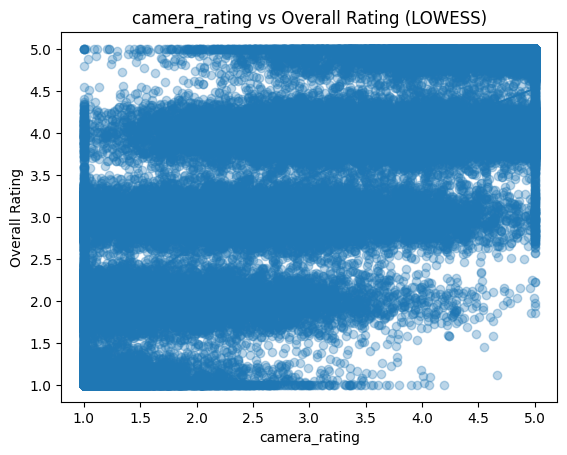

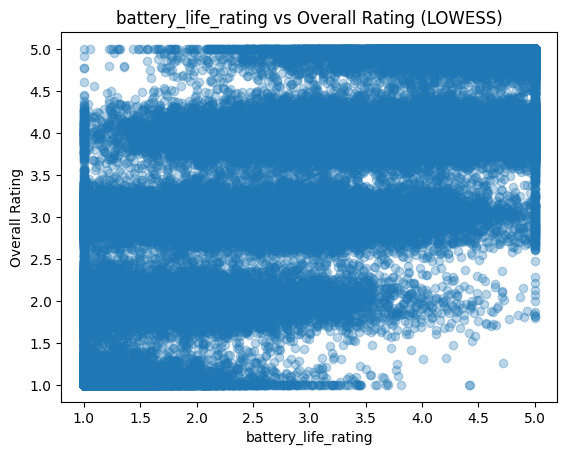

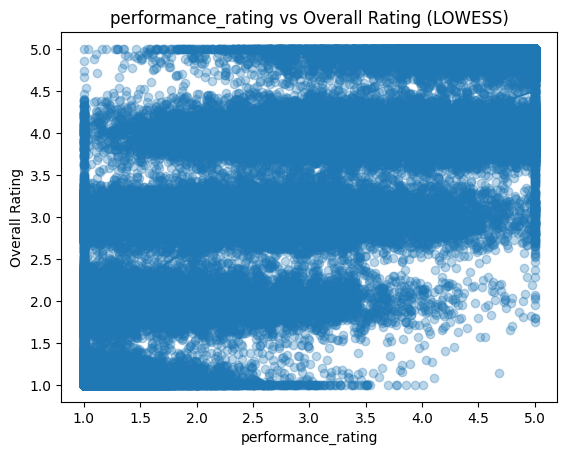

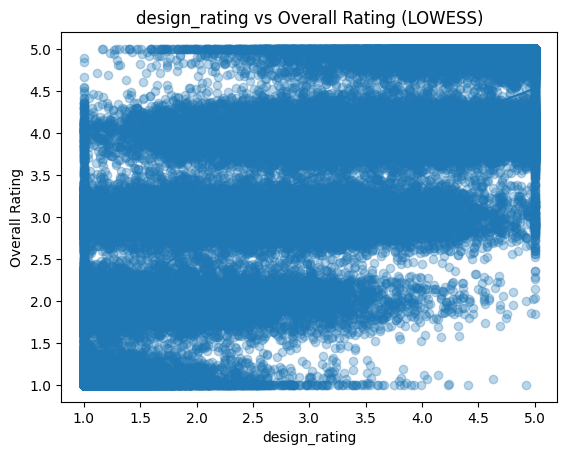

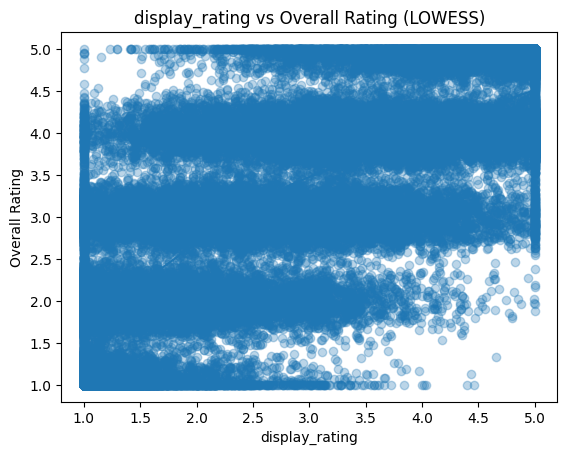

In [ ]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

specs = ["camera_rating", "battery_life_rating", "performance_rating", "design_rating", "display_rating"]

for spec in specs:
    x = df[spec]
    y = df["rating"]

    # LOWESS smoothing
    lowess = sm.nonparametric.lowess(y, x, frac=0.3)

    plt.figure()
    plt.scatter(x, y, alpha=0.3)
    plt.plot(lowess[:, 0], lowess[:, 1])
    plt.xlabel(spec)
    plt.ylabel("Overall Rating")
    plt.title(f"{spec} vs Overall Rating (LOWESS)")
    plt.show()


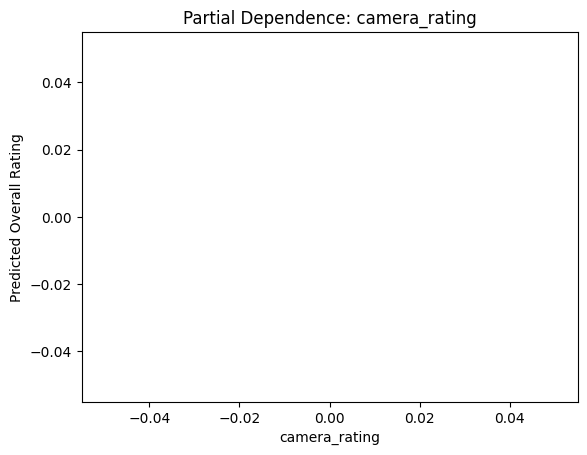

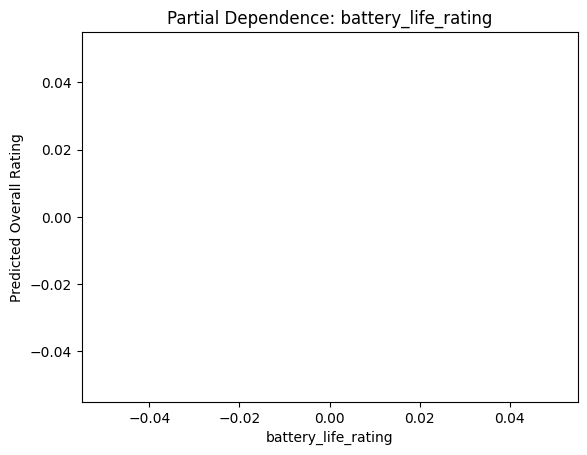

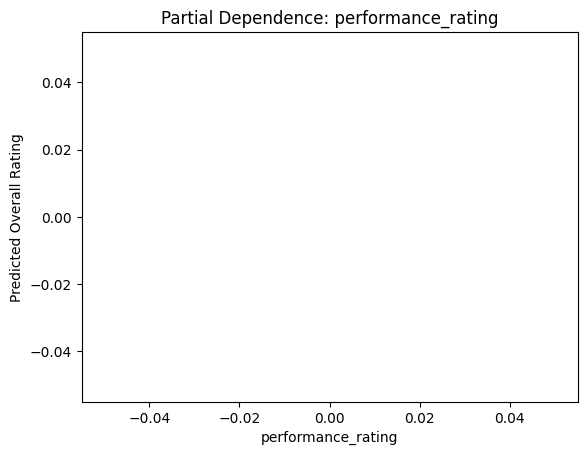

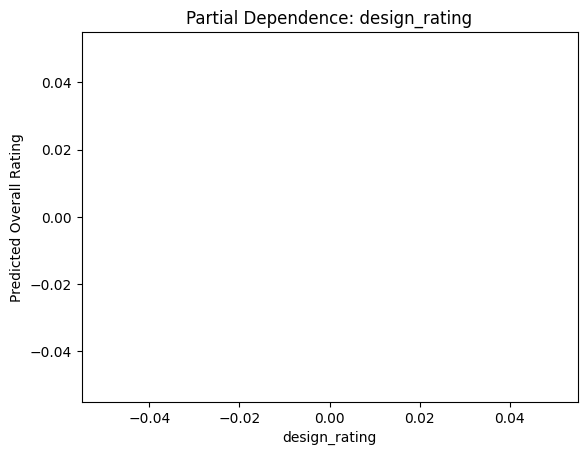

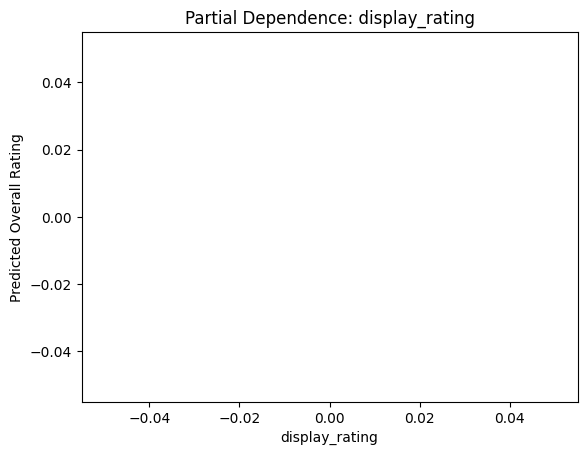

In [ ]:
import numpy as np

model = m_quad  # your fitted quadratic model

for spec in specs:
    x_vals = np.linspace(df[spec].min(), df[spec].max(), 100)
    temp = pd.DataFrame()

    for s in specs:
        temp[s + "_c"] = 0.0
        temp[s + "_c2"] = 0.0

    temp[spec + "_c"] = x_vals - df[spec].mean()
    temp[spec + "_c2"] = temp[spec + "_c"] ** 2

    preds = model.predict(temp)

    plt.figure()
    plt.plot(x_vals, preds)
    plt.xlabel(spec)
    plt.ylabel("Predicted Overall Rating")
    plt.title(f"Partial Dependence: {spec}")
    plt.show()


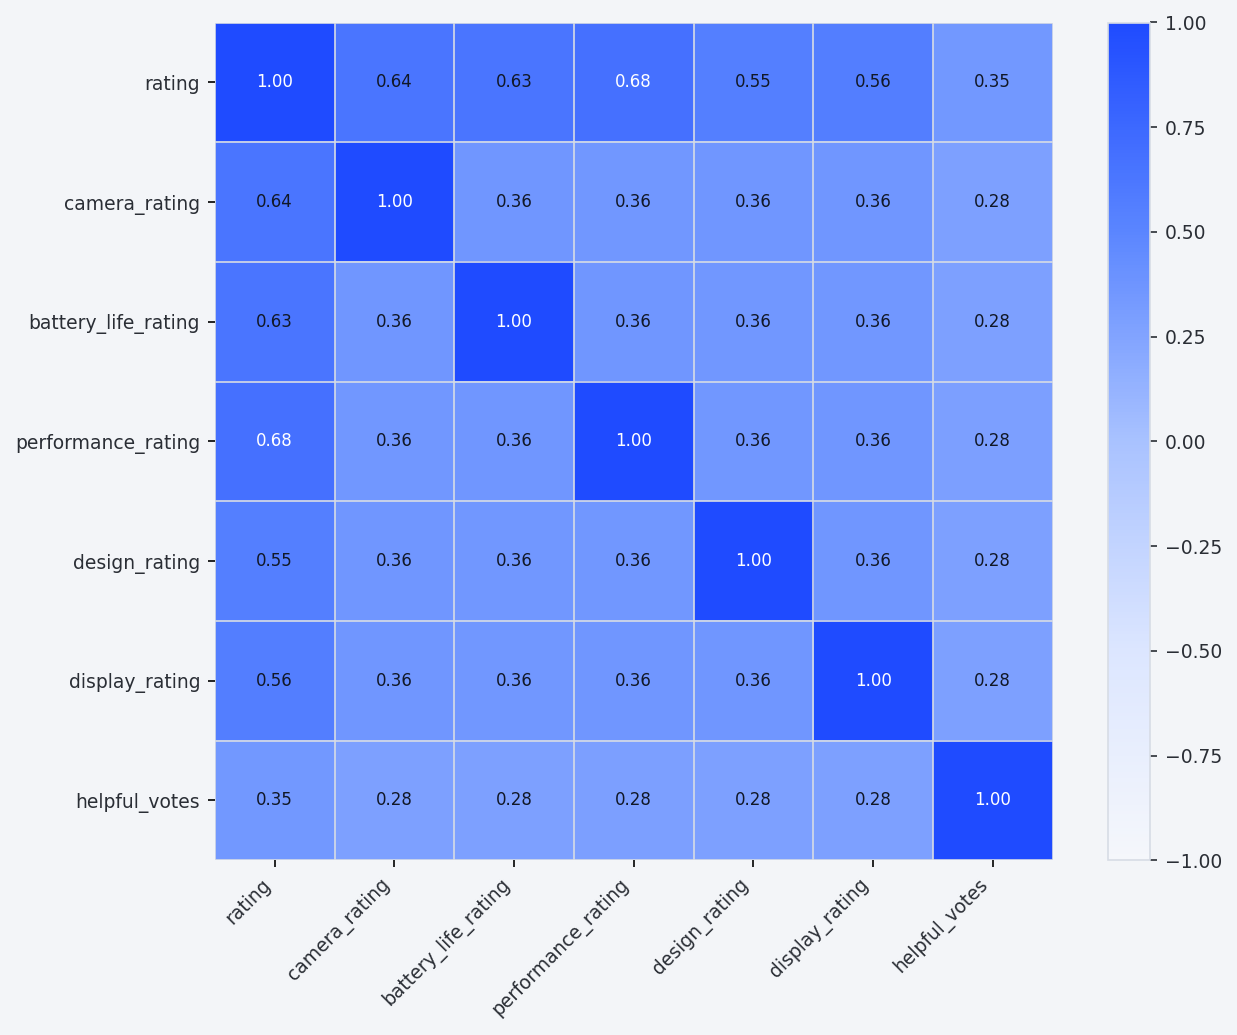

In [ ]:



import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# ---- choose columns for correlation ----
cols = [
    "rating",
    "camera_rating",
    "battery_life_rating",
    "performance_rating",
    "design_rating",
    "display_rating",
    "helpful_votes",
]

corr = df[cols].corr(numeric_only=True)

# ---- custom blue colormap (light -> deep blue) ----
blue_cmap = LinearSegmentedColormap.from_list(
    "blue_theme",
    ["#F5F7FB", "#DCE6FF", "#A9C2FF", "#5B86FF", "#1F4BFF"]
)

# ---- figure ----
fig, ax = plt.subplots(figsize=(10, 7), dpi=150)

# Graph-paper background
ax.set_facecolor("#F3F5F8")
fig.patch.set_facecolor("#F3F5F8")

# Heatmap
im = ax.imshow(corr.values, cmap=blue_cmap, vmin=-1, vmax=1)

# Ticks / labels
ax.set_xticks(np.arange(len(cols)))
ax.set_yticks(np.arange(len(cols)))
ax.set_xticklabels(cols, rotation=45, ha="right", fontsize=9, color="#2A2E35")
ax.set_yticklabels(cols, fontsize=9, color="#2A2E35")

# Subtle gridlines (graph-paper feel)
ax.set_xticks(np.arange(-0.5, len(cols), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(cols), 1), minor=True)
ax.grid(which="minor", color="#D7DCE5", linestyle="-", linewidth=0.8)
ax.tick_params(which="minor", bottom=False, left=False)

# Annotate correlation values
for i in range(len(cols)):
    for j in range(len(cols)):
        val = corr.values[i, j]
        ax.text(
            j, i, f"{val:.2f}",
            ha="center", va="center",
            fontsize=8,
            color="#111827" if abs(val) < 0.65 else "white"
        )

# Title (bold blue like your theme)


# Colorbar styled
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=9, colors="#2A2E35")
cbar.outline.set_edgecolor("#D7DCE5")

# Remove heavy frame
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()


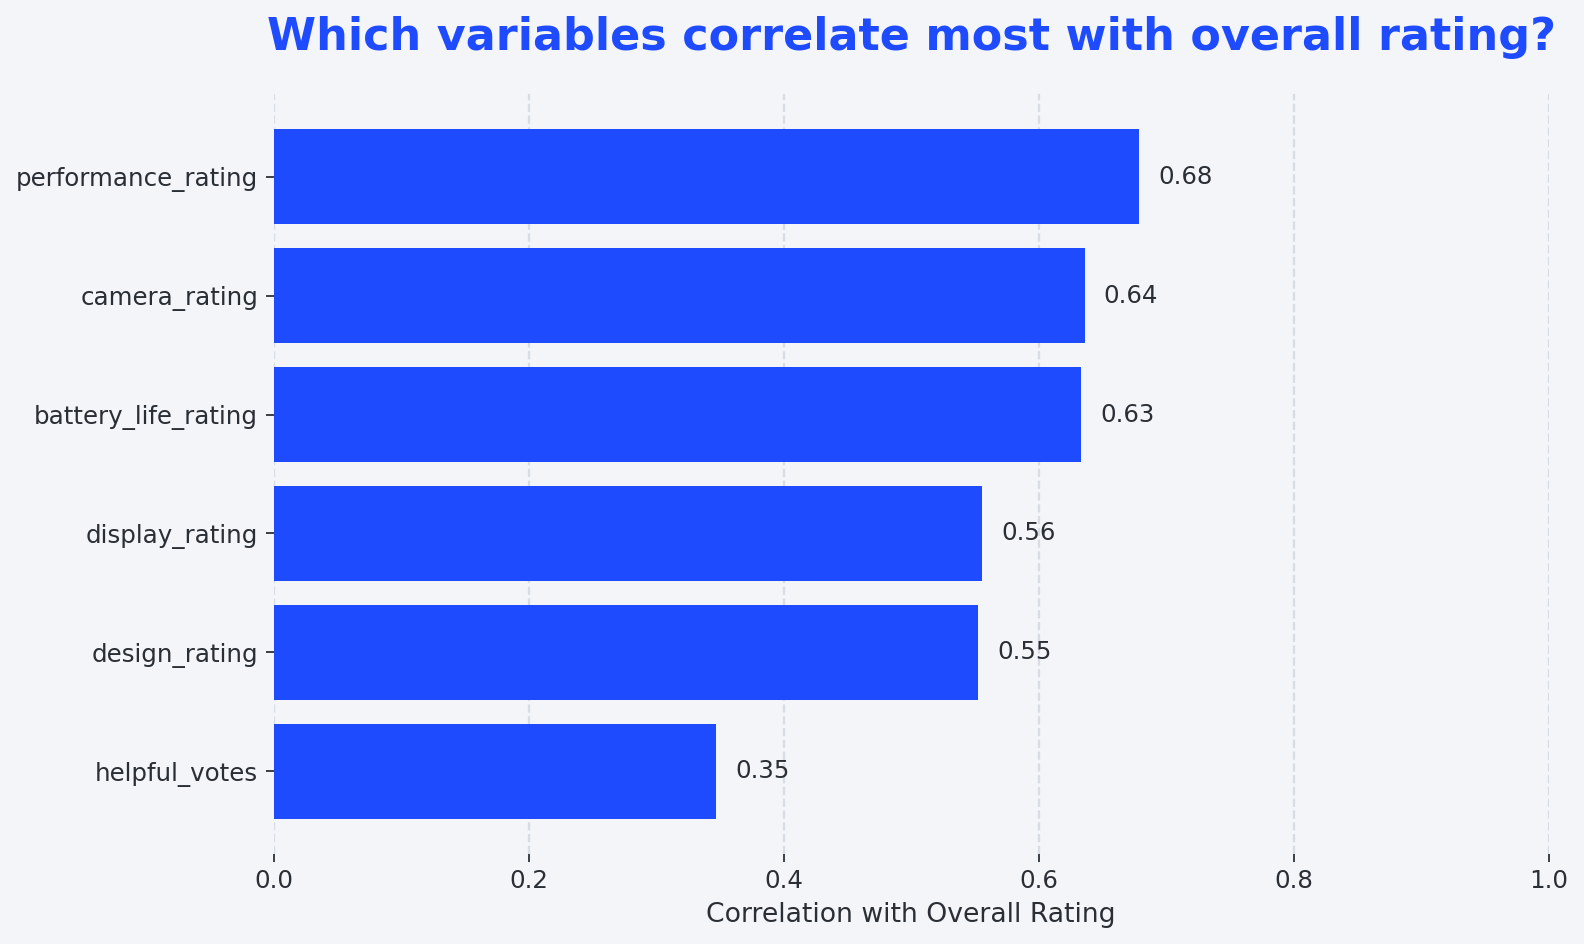

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

specs = ["camera_rating","battery_life_rating","performance_rating","design_rating","display_rating","helpful_votes"]

corr_with_rating = df[specs + ["rating"]].corr(numeric_only=True)["rating"].drop("rating").sort_values()

plt.figure(figsize=(10,6), dpi=160)
ax = plt.gca()

# Background styling
ax.set_facecolor("#F3F5F8")
plt.gcf().patch.set_facecolor("#F3F5F8")

# Bars
ax.barh(corr_with_rating.index, corr_with_rating.values, color="#1F4BFF")

# Gridlines (graph-paper look)
ax.xaxis.grid(True, linestyle="--", color="#D7DCE5", linewidth=1)
ax.set_axisbelow(True)

# Labels and title
ax.set_xlabel("Correlation with Overall Rating", fontsize=12, color="#2A2E35")
ax.set_title("Which variables correlate most with overall rating?", fontsize=20, fontweight="bold", color="#1F4BFF", pad=20)

# Limits
ax.set_xlim(0, 1)

# Tick styling
ax.tick_params(axis='both', labelsize=11, colors="#2A2E35")

# Remove spines for clean look
for spine in ax.spines.values():
    spine.set_visible(False)

# Value labels
for i, v in enumerate(corr_with_rating.values):
    ax.text(v + 0.015, i, f"{v:.2f}", va="center", fontsize=11, color="#2A2E35")

plt.tight_layout()
plt.show()


In [ ]:
df[["rating","camera_rating","battery_life_rating","performance_rating","design_rating","display_rating"]].skew()


,0
rating,-0.174044
camera_rating,0.206130
battery_life_rating,0.209338
performance_rating,0.202032
design_rating,0.215326
display_rating,0.204753


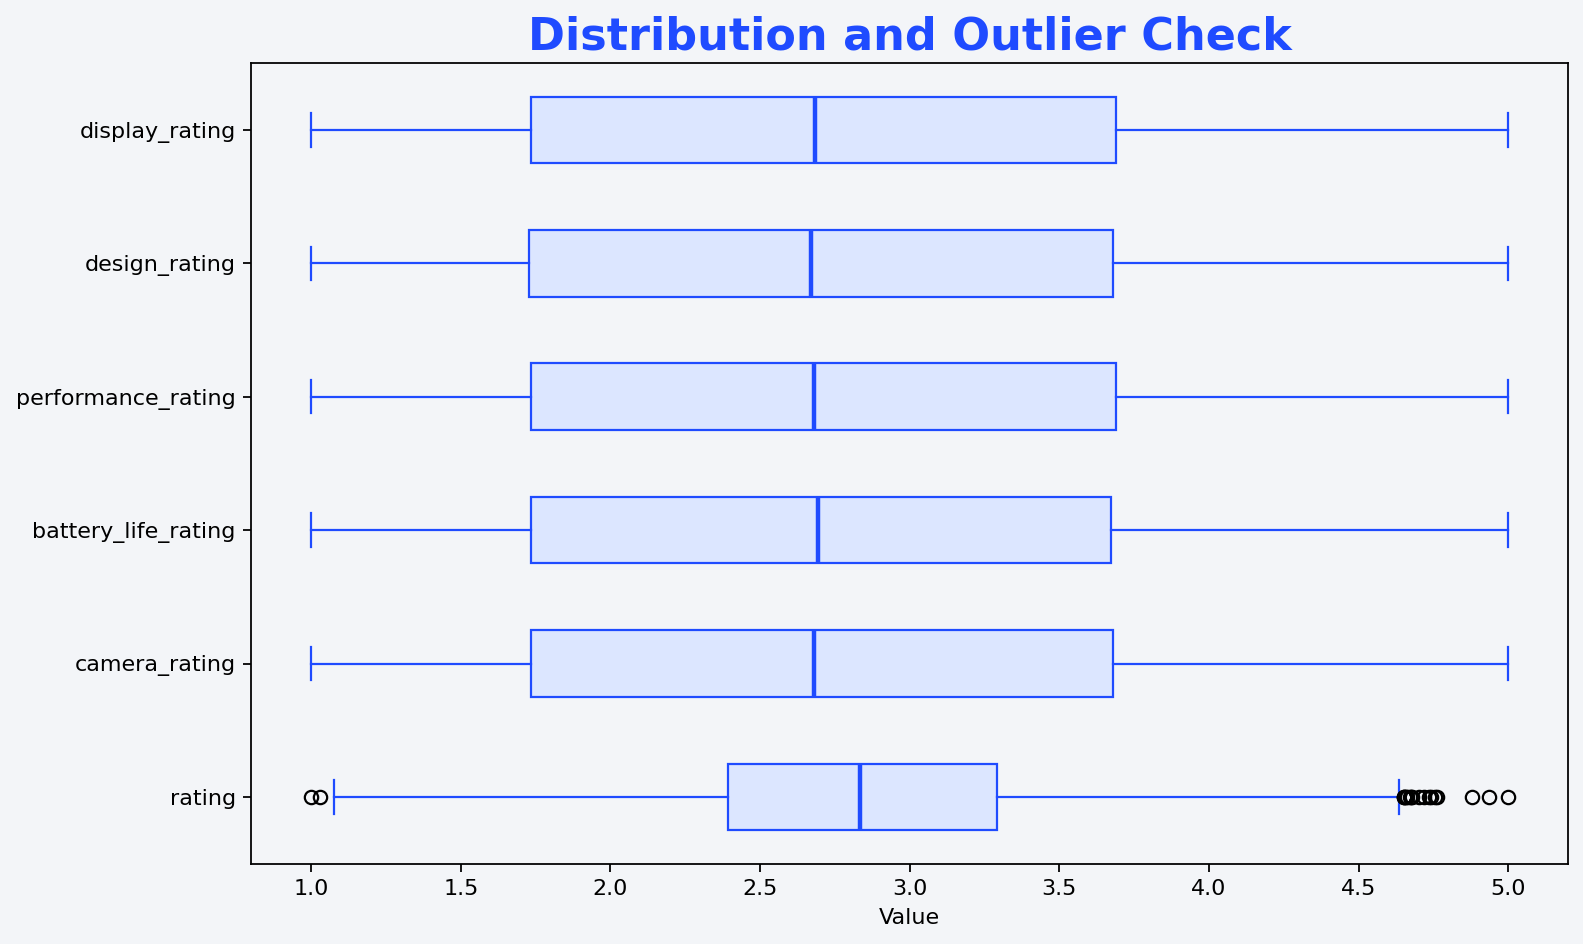

In [ ]:
import matplotlib.pyplot as plt

cols = ["rating", "camera_rating", "battery_life_rating", "performance_rating", "design_rating", "display_rating"]

plt.figure(figsize=(10, 6), dpi=160)
bp = plt.boxplot(df[cols], vert=False, patch_artist=True)

for box in bp["boxes"]:
    box.set(facecolor="#DCE6FF", edgecolor="#1F4BFF")
for whisker in bp["whiskers"]:
    whisker.set(color="#1F4BFF")
for cap in bp["caps"]:
    cap.set(color="#1F4BFF")
for median in bp["medians"]:
    median.set(color="#1F4BFF", linewidth=2)

plt.yticks(range(1, len(cols) + 1), cols)
plt.title("Distribution and Outlier Check", fontsize=20, fontweight="bold", color="#1F4BFF")
plt.xlabel("Value")
plt.gca().set_facecolor("#F3F5F8")
plt.gcf().patch.set_facecolor("#F3F5F8")

plt.tight_layout()
plt.show()



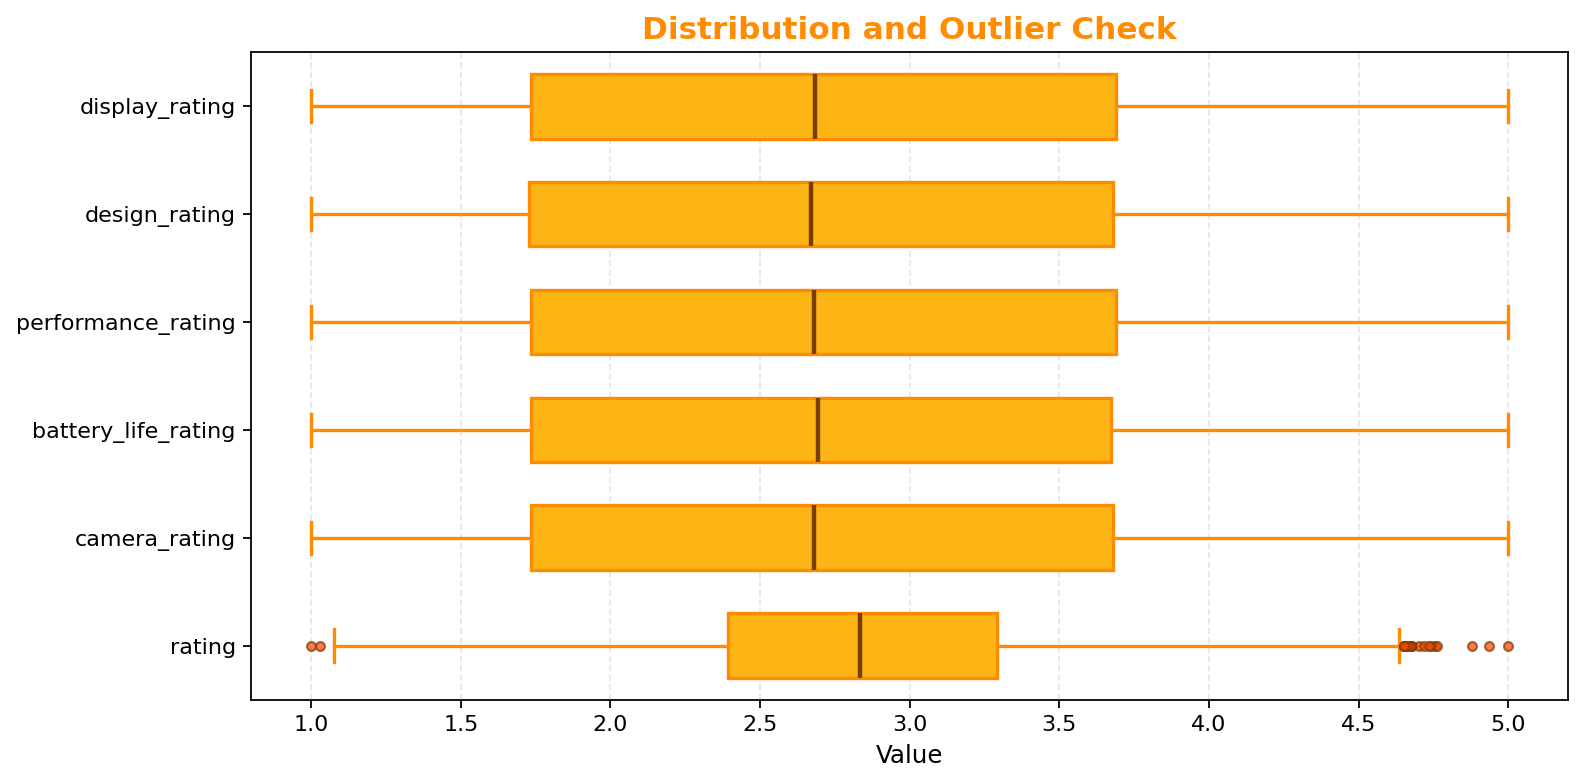

In [ ]:
import matplotlib.pyplot as plt

cols = ["rating", "camera_rating", "battery_life_rating",
        "performance_rating", "design_rating", "display_rating"]

data = [df[c] for c in cols]

plt.figure(figsize=(10, 5), dpi=160)

box = plt.boxplot(
    data,
    vert=False,
    patch_artist=True,
    widths=0.6,
    boxprops=dict(facecolor="#FDB515", edgecolor="#FF8C00", linewidth=1.5),
    whiskerprops=dict(color="#FF8C00", linewidth=1.5),
    capprops=dict(color="#FF8C00", linewidth=1.5),
    medianprops=dict(color="#7A3E00", linewidth=2),
    flierprops=dict(marker='o', markerfacecolor="#FF4500",
                    markeredgecolor="#7A3E00", markersize=4, alpha=0.7)
)

plt.yticks(range(1, len(cols) + 1), cols)
plt.xlabel("Value", fontsize=11)
plt.title("Distribution and Outlier Check", fontsize=14, fontweight="bold", color="#FF8C00")

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
df[["rating","camera_rating","battery_life_rating","performance_rating","design_rating","display_rating"]].describe().loc[["min","25%"]]


,rating,camera_rating,battery_life_rating,performance_rating,design_rating,display_rating
min,1.0,1.0,1.0,1.0,1.0,1.0
25%,2.0,1.0,1.0,1.0,1.0,1.0


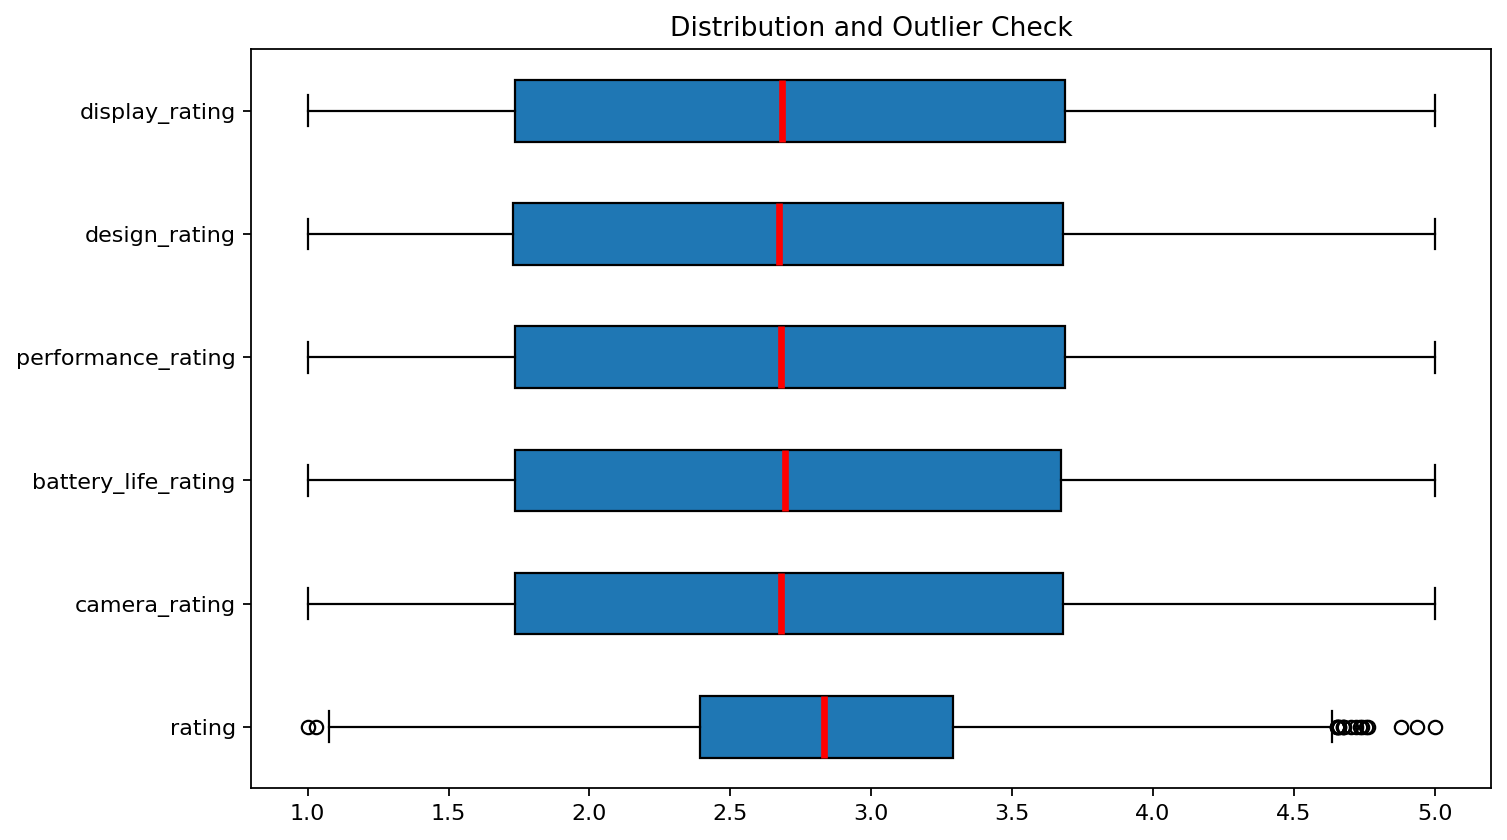

In [ ]:

import matplotlib.pyplot as plt

cols = ["rating", "camera_rating", "battery_life_rating", "performance_rating", "design_rating", "display_rating"]
plt.figure(figsize=(10,6), dpi=160)
bp = plt.boxplot(df[cols], vert=False, patch_artist=True,
                 medianprops=dict(color="red", linewidth=3))

plt.yticks(range(1,len(cols)+1), cols)
plt.title("Distribution and Outlier Check")
plt.show()


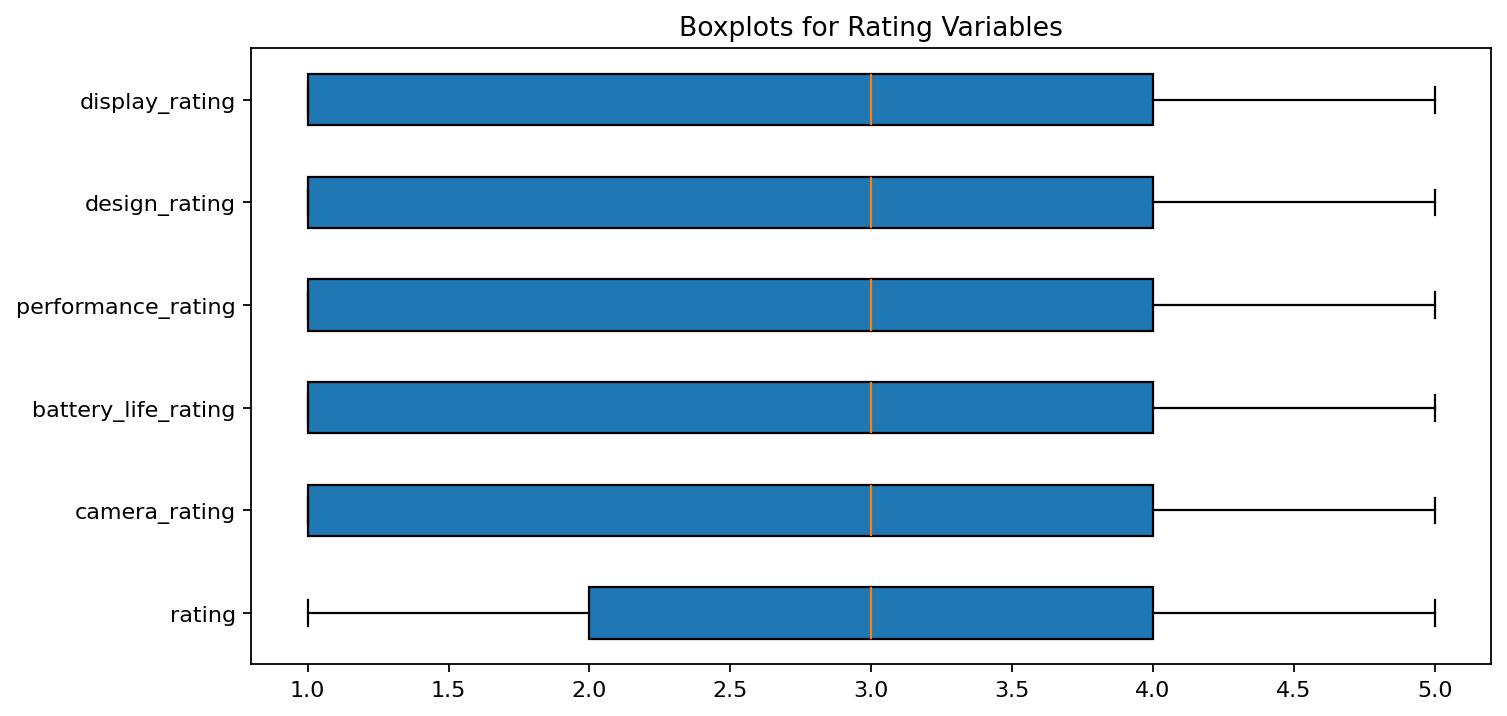

In [ ]:
rating_cols = ["rating","camera_rating","battery_life_rating","performance_rating","design_rating","display_rating"]
price_cols = ["price_usd"]

plt.figure(figsize=(10,5), dpi=160)
plt.boxplot(df[rating_cols], vert=False, patch_artist=True)
plt.yticks(range(1,len(rating_cols)+1), rating_cols)
plt.title("Boxplots for Rating Variables")
plt.show()



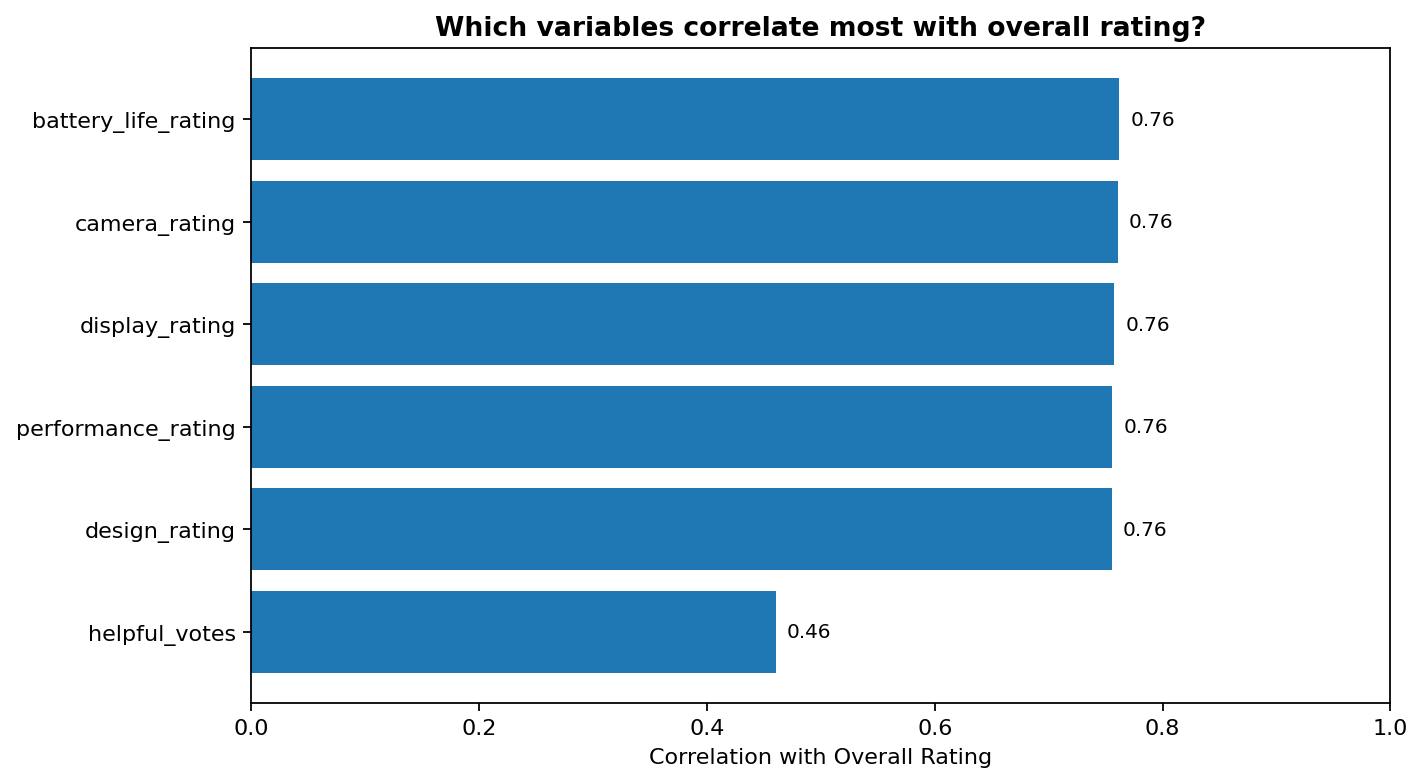

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

specs = ["camera_rating","battery_life_rating","performance_rating","design_rating","display_rating","helpful_votes"]

corr_with_rating = df[specs + ["rating"]].corr(numeric_only=True)["rating"].drop("rating").sort_values()

plt.figure(figsize=(9,5), dpi=160)
plt.barh(corr_with_rating.index, corr_with_rating.values)
plt.xlabel("Correlation with Overall Rating")
plt.title("Which variables correlate most with overall rating?", fontweight="bold")
plt.xlim(0, 1)

# value labels
for i, v in enumerate(corr_with_rating.values):
    plt.text(v + 0.01, i, f"{v:.2f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

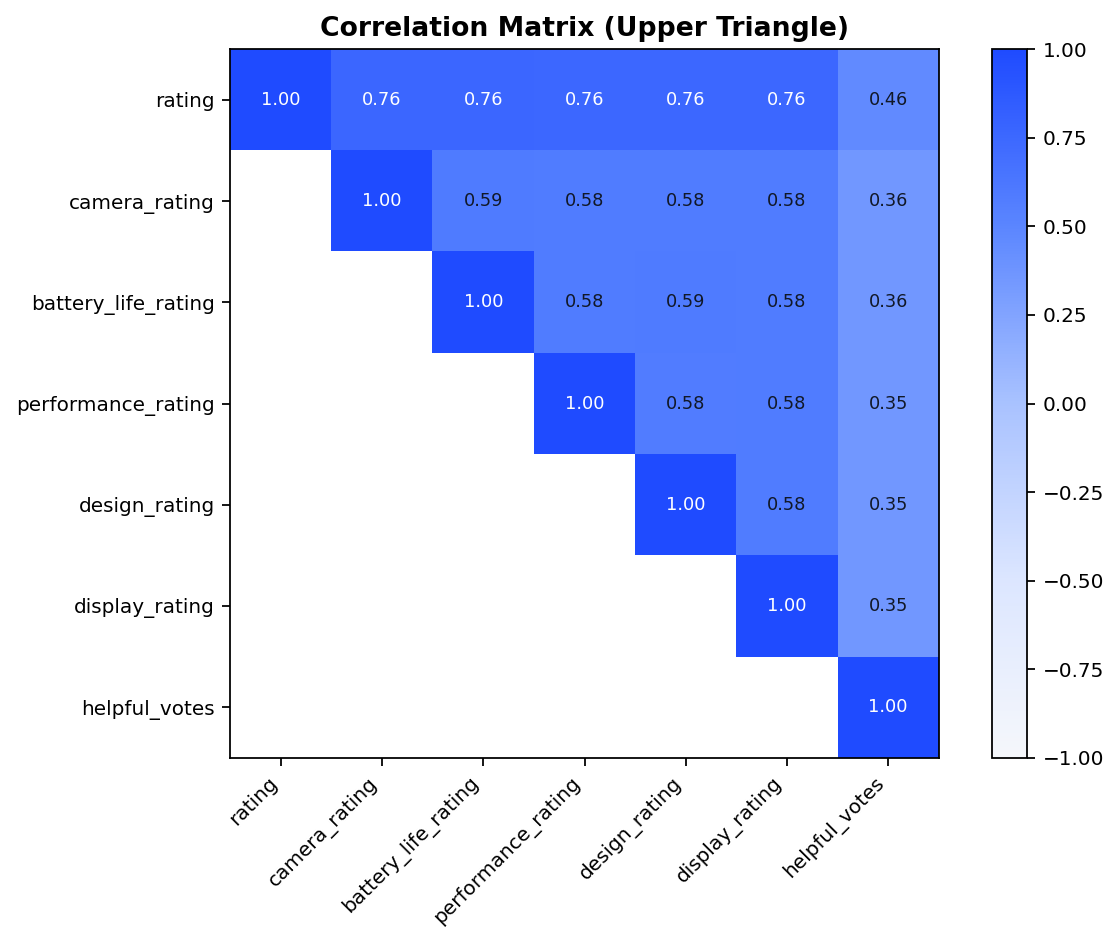

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

cols = ["rating","camera_rating","battery_life_rating","performance_rating","design_rating","display_rating","helpful_votes"]
corr = df[cols].corr(numeric_only=True)

# mask lower triangle
mask = np.tril(np.ones_like(corr, dtype=bool), k=-1)
corr_masked = corr.mask(mask)

blue_cmap = LinearSegmentedColormap.from_list(
    "blue_theme", ["#F5F7FB","#DCE6FF","#A9C2FF","#5B86FF","#1F4BFF"]
)

plt.figure(figsize=(9,6), dpi=160)
plt.imshow(corr_masked, cmap=blue_cmap, vmin=-1, vmax=1)

plt.xticks(range(len(cols)), cols, rotation=45, ha="right", fontsize=9)
plt.yticks(range(len(cols)), cols, fontsize=9)

# annotate
for i in range(len(cols)):
    for j in range(len(cols)):
        if not np.isnan(corr_masked.iloc[i, j]):
            val = corr_masked.iloc[i, j]
            plt.text(j, i, f"{val:.2f}", ha="center", va="center",
                     fontsize=8, color="white" if abs(val) > 0.65 else "#111827")

plt.title("Correlation Matrix (Upper Triangle)", fontweight="bold")
cbar = plt.colorbar(fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=9)

plt.tight_layout()
plt.show()


In [ ]:

import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler


In [ ]:
X = df[['camera_rating', 'battery_life_rating', 'performance_rating', 'design_rating', 'display_rating']]
y = df['rating']
X_const = sm.add_constant(X)
model = sm.OLS(y, X_const).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.784
Model:                            OLS   Adj. R-squared:                  0.784
Method:                 Least Squares   F-statistic:                 3.634e+04
Date:                Sun, 04 Jan 2026   Prob (F-statistic):               0.00
Time:                        14:45:05   Log-Likelihood:                -7537.9
No. Observations:               50000   AIC:                         1.509e+04
Df Residuals:                   49994   BIC:                         1.514e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   1.1243    

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif)


              Variable       VIF
0        camera_rating  7.787767
1  battery_life_rating  7.773060
2   performance_rating  7.703339
3        design_rating  7.735009
4       display_rating  7.779318


In [ ]:
X_nl = X.copy()
for col in X.columns:
    X_nl[col+"_sq"] = X[col]**2

X_nl = sm.add_constant(X_nl)
model_nl = sm.OLS(y, X_nl).fit()
print(model_nl.summary())


                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.784
Model:                            OLS   Adj. R-squared:                  0.784
Method:                 Least Squares   F-statistic:                 1.817e+04
Date:                Sun, 04 Jan 2026   Prob (F-statistic):               0.00
Time:                        14:45:27   Log-Likelihood:                -7537.3
No. Observations:               50000   AIC:                         1.510e+04
Df Residuals:                   49989   BIC:                         1.519e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      1

In [ ]:
import pandas as pd
import statsmodels.api as sm
from itertools import combinations

specs = ["camera_rating", "battery_life_rating", "performance_rating", "design_rating", "display_rating"]
df_int = df.copy()
for col in specs:
    df_int[col + "_c"] = df_int[col] - df_int[col].mean()

centered = [c + "_c" for c in specs]
interaction_terms = []
for a, b in combinations(centered, 2):
    name = f"{a}_x_{b}"
    df_int[name] = df_int[a] * df_int[b]
    interaction_terms.append(name)
y = df_int["rating"]

X_main = sm.add_constant(df_int[centered])
X_full = sm.add_constant(df_int[centered + interaction_terms])

model_main = sm.OLS(y, X_main).fit()
model_full = sm.OLS(y, X_full).fit()
print("Main model Adj R²:", model_main.rsquared_adj)
print("Interaction model Adj R²:", model_full.rsquared_adj)
print("Δ Adj R²:", model_full.rsquared_adj - model_main.rsquared_adj)
results = pd.DataFrame({
    "interaction": interaction_terms,
    "coef": [model_full.params[t] for t in interaction_terms],
    "p_value": [model_full.pvalues[t] for t in interaction_terms]
})

results["significant_0.05"] = results["p_value"] < 0.05
results.sort_values("p_value", inplace=True)
print(results)


Main model Adj R²: 0.7841860171850514
Interaction model Adj R²: 0.7842211566021999
Δ Adj R²: 3.5139417148499774e-05
                                    interaction      coef   p_value  \
3            camera_rating_c_x_display_rating_c  0.002358  0.030614   
6      battery_life_rating_c_x_display_rating_c -0.002229  0.040856   
9            design_rating_c_x_display_rating_c  0.001641  0.130268   
0       camera_rating_c_x_battery_life_rating_c -0.001598  0.142995   
4  battery_life_rating_c_x_performance_rating_c  0.001506  0.163852   
5       battery_life_rating_c_x_design_rating_c  0.001207  0.265176   
7        performance_rating_c_x_design_rating_c  0.000643  0.551660   
8       performance_rating_c_x_display_rating_c -0.000381  0.723784   
1        camera_rating_c_x_performance_rating_c  0.000063  0.953922   
2             camera_rating_c_x_design_rating_c  0.000047  0.965401   

   significant_0.05  
3              True  
6              True  
9             False  
0             

In [ ]:
import pandas as pd
import statsmodels.formula.api as smf

# Make sure brand is treated as categorical
# df['brand'] = df['brand'].astype('category')
model_specs = smf.ols(
    'rating ~ camera_rating + battery_life_rating + performance_rating + design_rating + display_rating',
    data=df
).fit()

print(model_specs.summary())
model_full = smf.ols(
    'rating ~ camera_rating + battery_life_rating + performance_rating + design_rating + display_rating + price_usd + C(brand)',
    data=df
).fit()

print("Base model R²:", model_specs.rsquared_adj)
print("Full model R²:", model_full.rsquared_adj)



                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.864
Model:                            OLS   Adj. R-squared:                  0.864
Method:                 Least Squares   F-statistic:                 6.327e+04
Date:                Sat, 03 Jan 2026   Prob (F-statistic):               0.00
Time:                        14:53:56   Log-Likelihood:                -32255.
No. Observations:               50000   AIC:                         6.452e+04
Df Residuals:                   49994   BIC:                         6.458e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               0.2550    

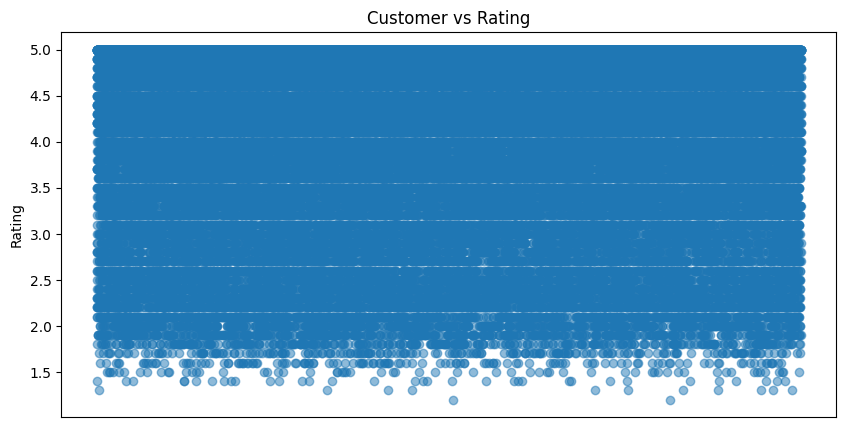

,customer_code,rating
customer_code,1.000000,-0.001673
rating,-0.001673,1.000000


In [ ]:
df['customer_name'].value_counts().head(10)
duplicate_customers = df[df['customer_name'].duplicated(keep=False)]
duplicate_customers.groupby('customer_name')['rating'].var().head(10)
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.scatter(df['customer_name'], df['rating'], alpha=0.5)
plt.xticks([], [])  # hide long labels
plt.title("Customer vs Rating")
plt.ylabel("Rating")
plt.show()

df['customer_code'] = df['customer_name'].astype('category').cat.codes
df[['customer_code', 'rating']].corr()


In [ ]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# --- columns ---
specs = ["camera_rating", "battery_life_rating", "performance_rating", "design_rating", "display_rating"]
y_col = "rating"

# ------------------------------------------------------------
# 1) Center specs (important when adding squares)
# ------------------------------------------------------------
df = df.copy()
for c in specs:
    df[c + "_c"] = df[c] - df[c].mean()
    df[c + "_c2"] = df[c + "_c"] ** 2

# ------------------------------------------------------------
# 2) Fit linear vs quadratic models (OLS)
# ------------------------------------------------------------
linear_formula = y_col + " ~ " + " + ".join([c + "_c" for c in specs])
quad_formula   = y_col + " ~ " + " + ".join([c + "_c" for c in specs] + [c + "_c2" for c in specs])

m_linear = smf.ols(linear_formula, data=df).fit()
m_quad   = smf.ols(quad_formula, data=df).fit()

print("=== Model fit (no ANOVA) ===")
print(f"Linear:   Adj R²={m_linear.rsquared_adj:.6f} | AIC={m_linear.aic:.2f} | BIC={m_linear.bic:.2f}")
print(f"Quadratic:Adj R²={m_quad.rsquared_adj:.6f} | AIC={m_quad.aic:.2f} | BIC={m_quad.bic:.2f}")

# ------------------------------------------------------------
# 3) Diminishing returns check (per spec): squared term < 0 and significant
# ------------------------------------------------------------
rows = []
for c in specs:
    b_lin = m_quad.params[c + "_c"]
    p_lin = m_quad.pvalues[c + "_c"]
    b_sq  = m_quad.params[c + "_c2"]
    p_sq  = m_quad.pvalues[c + "_c2"]
    rows.append([c, b_lin, p_lin, b_sq, p_sq, (b_sq < 0) and (p_sq < 0.05)])

result = pd.DataFrame(
    rows,
    columns=["Spec", "Linear_coef", "Linear_p", "Squared_coef", "Squared_p", "Diminishing_returns?"]
)
print("\n=== Diminishing returns evidence (look at Squared_coef & Squared_p) ===")
print(result)

# ------------------------------------------------------------
# 4) Cross-validation comparison (NO ANOVA):
#    If quadratic model has lower CV RMSE, it generalizes better
# ------------------------------------------------------------
X_linear = df[[c + "_c" for c in specs]].values
X_quad   = df[[c + "_c" for c in specs] + [c + "_c2" for c in specs]].values
y = df[y_col].values

kf = KFold(n_splits=5, shuffle=True, random_state=42)

def cv_rmse(X):
    rmses = []
    for train, test in kf.split(X):
        model = LinearRegression()
        model.fit(X[train], y[train])
        pred = model.predict(X[test])
        rmse = np.sqrt(mean_squared_error(y[test], pred))
        rmses.append(rmse)
    return float(np.mean(rmses)), float(np.std(rmses))

rmse_lin_mean, rmse_lin_sd = cv_rmse(X_linear)
rmse_quad_mean, rmse_quad_sd = cv_rmse(X_quad)

print("\n=== 5-fold Cross-Validation (lower RMSE = better) ===")
print(f"Linear RMSE:    {rmse_lin_mean:.6f} ± {rmse_lin_sd:.6f}")
print(f"Quadratic RMSE: {rmse_quad_mean:.6f} ± {rmse_quad_sd:.6f}")


=== Model fit (no ANOVA) ===
Linear:   Adj R²=0.863524 | AIC=64522.85 | BIC=64575.76
Quadratic:Adj R²=0.870786 | AIC=61793.74 | BIC=61890.76

=== Diminishing returns evidence (look at Squared_coef & Squared_p) ===
                  Spec  Linear_coef  Linear_p  Squared_coef     Squared_p  \
0        camera_rating     0.220123       0.0     -0.023013  7.731562e-70   
1  battery_life_rating     0.216731       0.0     -0.021114  2.014993e-59   
2   performance_rating     0.213970       0.0     -0.023431  3.288987e-73   
3        design_rating     0.213092       0.0     -0.021862  3.241106e-63   
4       display_rating     0.213885       0.0     -0.020781  1.154647e-57   

   Diminishing_returns?  
0                  True  
1                  True  
2                  True  
3                  True  
4                  True  

=== 5-fold Cross-Validation (lower RMSE = better) ===
Linear RMSE:    0.461285 ± 0.002995
Quadratic RMSE: 0.448890 ± 0.003172


rating
1.2        2
1.3       11
1.4       34
1.5       61
1.6      128
1.7      213
1.8      373
1.9      546
2.0      693
2.1      883
2.2      933
2.3      945
2.4      906
2.5      892
2.6      951
2.7      828
2.8      814
2.9      848
3.0      911
3.1      961
3.2     1000
3.3     1020
3.4     1133
3.5     1237
3.6     1265
3.7     1236
3.8     1337
3.9     1400
4.0     1417
4.1     1458
4.2     1672
4.3     1795
4.4     1809
4.5     1905
4.6     2035
4.7     2053
4.8     1994
4.9     2007
5.0    10294
Name: count, dtype: int64


,battery_life_rating,camera_rating,performance_rating,display_rating,design_rating
battery_life_rating,1.000000,0.560193,0.557701,0.569953,0.571599
camera_rating,0.560193,1.000000,0.551925,0.567392,0.566244
performance_rating,0.557701,0.551925,1.000000,0.566198,0.562199
display_rating,0.569953,0.567392,0.566198,1.000000,0.579132
design_rating,0.571599,0.566244,0.562199,0.579132,1.000000


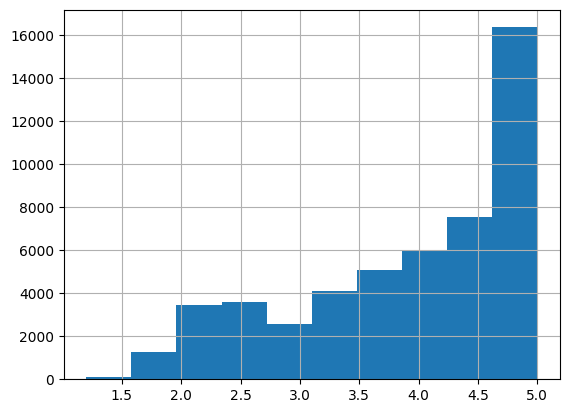

In [ ]:

# 1. Check distribution of all ratings
df['rating'].hist(bins=10)

# 2. Check how many unique rating values exist
print(df['rating'].value_counts().sort_index())

# 3. Compare variance across categories
df[['battery_life_rating', 'camera_rating', 'performance_rating','display_rating','design_rating']].describe()

# 4. See if all three columns correlate highly
df[['battery_life_rating', 'camera_rating', 'performance_rating','display_rating','design_rating']].corr()


In [ ]:
# Null Value analysis
print("\n1. Total null values in each column:")
print(df.isnull().sum())

# Method 2: Check percentage of null values in each column
print("\n2. Percentage of null values in each column:")
print((df.isnull().sum() / len(df)) * 100)

# Method 3: Get columns with null values and their count
null_columns = df.columns[df.isnull().any()]
print("\n3. Columns containing null values:")
print(df[null_columns].isnull().sum())

# Method 4: Check if any null values exist in entire dataset
print("\n4. Are there any null values in entire dataset?")
print(df.isnull().values.any())

# Method 5: Get total count of null values in dataset
print("\n5. Total number of null values in entire dataset:")
print(df.isnull().sum().sum())




1. Total null values in each column:
review_id               0
customer_name           0
age                     0
brand                   0
model                   0
price_usd               0
price_local             0
currency                0
exchange_rate_to_usd    0
rating                  0
review_text             0
sentiment               0
country                 0
language                0
review_date             0
verified_purchase       0
battery_life_rating     0
camera_rating           0
performance_rating      0
design_rating           0
display_rating          0
review_length           0
word_count              0
helpful_votes           0
source                  0
dtype: int64

2. Percentage of null values in each column:
review_id               0.0
customer_name           0.0
age                     0.0
brand                   0.0
model                   0.0
price_usd               0.0
price_local             0.0
currency                0.0
exchange_rate_to_usd    0.0
r

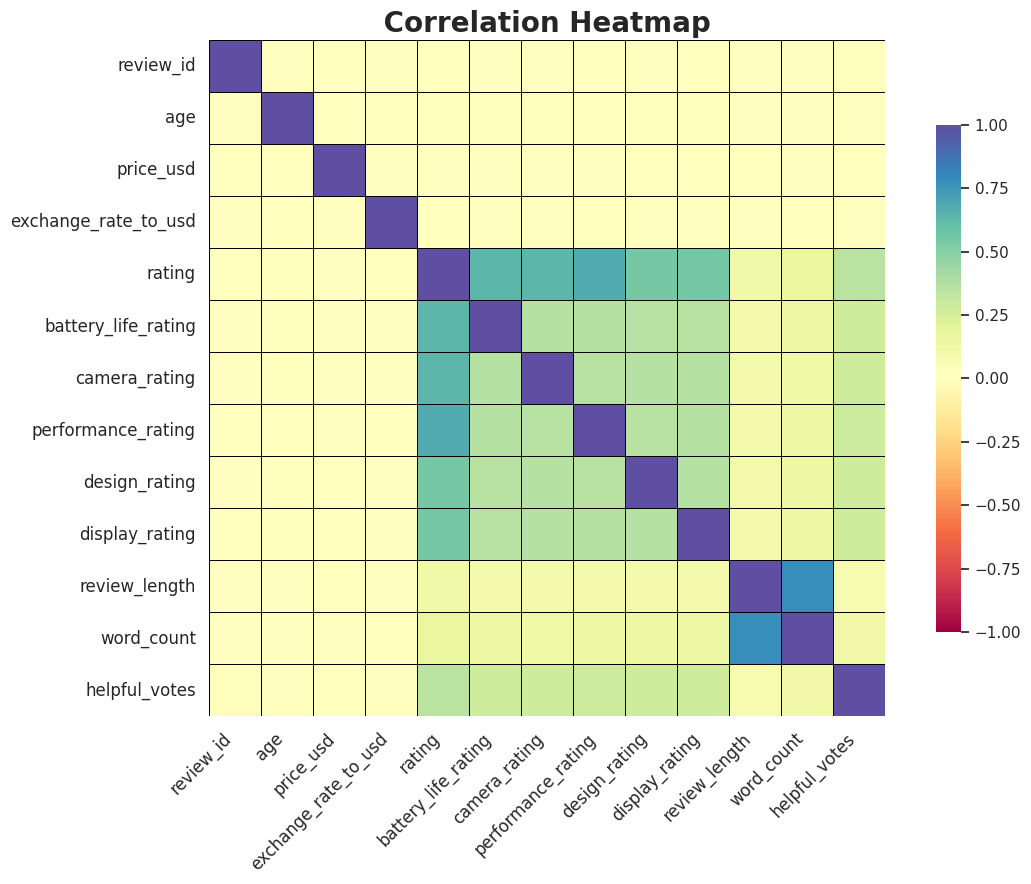

In [ ]:
# Correlation heatmap

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numerical columns
num_df = df.select_dtypes(include=['number'])

# Compute correlation matrix
corr = num_df.corr()

# Plot using a beautiful diverging palette
plt.figure(figsize=(12, 9))
sns.set_theme(style="white")

heatmap = sns.heatmap(corr,
                      vmin=-1, vmax=1,
                      cmap="Spectral",      # 🔥 stunning colormap
                      linewidths=0.7,       # space between cells
                      linecolor='black',    # grid color
                      square=True,
                      cbar_kws={"shrink": .75})

plt.title(" Correlation Heatmap ",
          fontdict={"fontsize": 20, "fontweight": "bold"})
plt.xticks(fontsize=12, rotation=45, ha='right')
plt.yticks(fontsize=12, rotation=0)
plt.tight_layout()
plt.show()


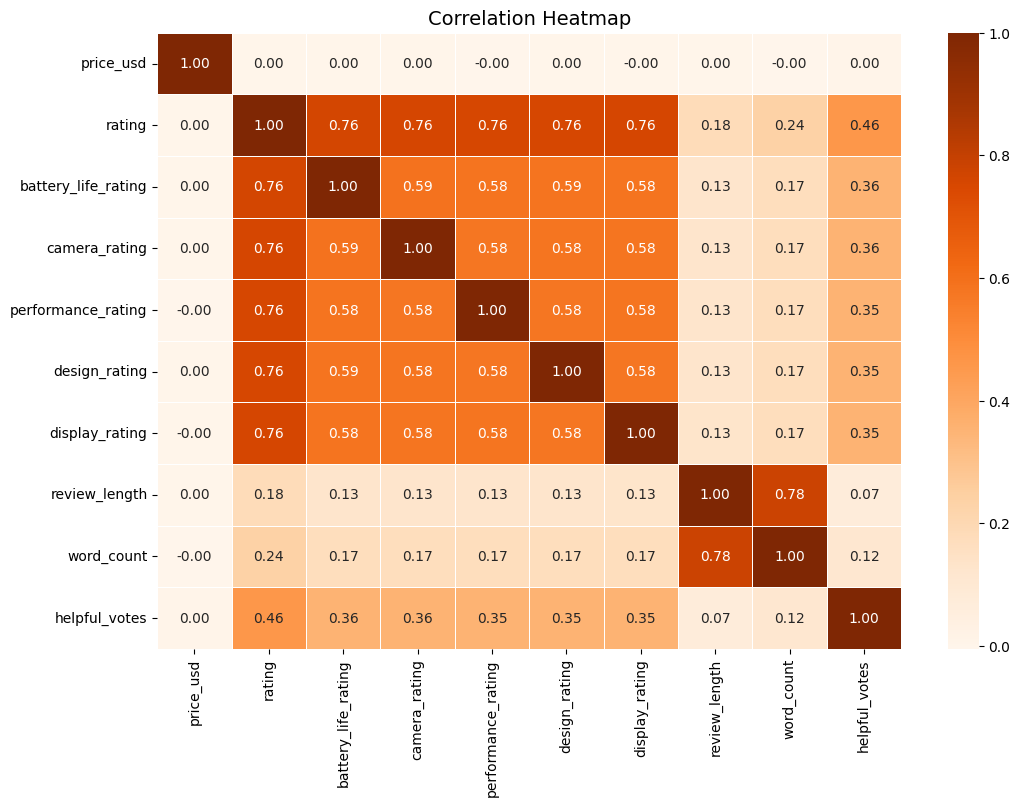

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset
df = pd.read_csv("Mobile.csv")

# Columns to exclude
exclude_cols = ["review_id", "age", "price", "exchange_rate_to_usd"]

# Select only numeric columns
numeric_df = df.select_dtypes(include=["number"])

# Drop excluded numeric columns
numeric_df = numeric_df.drop(columns=[col for col in exclude_cols if col in numeric_df.columns])

# Ensure poor_count is included if it's numeric
# (It will automatically stay because we are not excluding it)

# Compute correlation matrix
corr = numeric_df.corr()

# Plot
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="Oranges",     # 🔶 Orange color palette
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=14)
plt.show()


In [ ]:
#Implementing scenario where user has given high rating to camera and low rating to battery
low_batt_high_cam = df[
    (df['battery_life_rating'] <= 2) &
    (df['camera_rating'] >= 4)
]

print("Implementing scenario where user has given high rating to camera and low rating to battery")
print(low_batt_high_cam['rating'].mean())

high_batt_low_cam = df[
    (df['battery_life_rating'] >= 4) &
    (df['camera_rating'] <= 2)
]

#Implementing scenario with high battery and low camera
print("Implementing scenario with high battery and low camera")

print(high_batt_low_cam['rating'].mean())

low_batt_low_cam = df[
    (df['battery_life_rating'] <= 2) &
    (df['camera_rating'] <= 2)
]

print("Implementing scenario with low battery and low camera")
print(low_batt_low_cam['rating'].mean())

df['battery_level'] = pd.cut(
    df['battery_life_rating'],
    bins=[0, 2.4, 3.4, 5],
    labels=['Poor', 'Medium', 'High']
)

df['camera_level'] = pd.cut(
    df['camera_rating'],
    bins=[0, 2.4, 3.4, 5],
    labels=['Poor', 'Medium', 'High']
)

df['performance_level'] = pd.cut(
    df['performance_rating'],
    bins=[0, 2.4, 3.4, 5],
    labels=['Poor', 'Medium', 'High']
)

# Count how many P/M/H per row
df['poor_count'] = (df[['battery_level','camera_level','performance_level']] == 'Poor').sum(axis=1)
df['medium_count'] = (df[['battery_level','camera_level','performance_level']] == 'Medium').sum(axis=1)
df['high_count'] = (df[['battery_level','camera_level','performance_level']] == 'High').sum(axis=1)

# Filter rows with exactly one Poor, one Medium, one High
combo = df[
    (df['poor_count'] == 1) &
    (df['medium_count'] == 1) &
    (df['high_count'] == 1)
]

combo['rating'].mean()


import pandas as pd

# -----------------------------------------
# 1. Categorize Battery, Camera, Performance into Poor / Medium / High
# -----------------------------------------

df['battery_level'] = pd.cut(
    df['battery_life_rating'],
    bins=[0, 2.4, 3.4, 5],
    labels=['Poor', 'Medium', 'High']
)

df['camera_level'] = pd.cut(
    df['camera_rating'],
    bins=[0, 2.4, 3.4, 5],
    labels=['Poor', 'Medium', 'High']
)

df['performance_level'] = pd.cut(
    df['performance_rating'],
    bins=[0, 2.4, 3.4, 5],
    labels=['Poor', 'Medium', 'High']
)

# -----------------------------------------
# 2. Filter the exact case:
#    Poor Battery + Poor Performance + Very Good (High) Camera
# -----------------------------------------

poor_batt_poor_perf_high_cam = df[
    (df['battery_level'] == 'Poor') &
    (df['performance_level'] == 'Poor') &
    (df['camera_level'] == 'High')
]

# -----------------------------------------
# 3. Calculate average final rating for this scenario
# -----------------------------------------

avg_rating = poor_batt_poor_perf_high_cam['rating'].mean()

# -----------------------------------------
# 4. Count how many rows match this scenario
# -----------------------------------------

row_count = poor_batt_poor_perf_high_cam.shape[0]

# -----------------------------------------
# 5. Print results
# -----------------------------------------




sentiment_percentage = (
    poor_batt_poor_perf_high_cam['sentiment'].value_counts(normalize=True) * 100
).round(2)

print("Sentiment percentage for poor battery and high camera (%):")
print(sentiment_percentage)

sentiment_counts = poor_batt_poor_perf_high_cam['sentiment'].value_counts()
print("Sentiment counts for poor battery poor performance and high cam:")
print(sentiment_counts)







Implementing scenario where user has given high rating to camera and low rating to battery
4.276612903225806
Implementing scenario with high battery and low camera
4.263995609220637
Implementing scenario with low battery and low camera
2.796855513985391
Sentiment percentage for poor battery and high camera (%):
sentiment
Positive    46.60
Neutral     38.18
Negative    15.22
Name: proportion, dtype: float64
Sentiment counts for poor battery poor performance and high cam:
sentiment
Positive    404
Neutral     331
Negative    132
Name: count, dtype: int64


In [ ]:
# -----------------------------------------
# 1. Categorize Battery, Camera, Performance into Poor / Medium / High
#    (Only run this once – if you already created these columns, skip)
# -----------------------------------------

df['battery_level'] = pd.cut(
    df['battery_life_rating'],
    bins=[0, 2.4, 3.4, 5],
    labels=['Poor', 'Medium', 'High']
)

df['camera_level'] = pd.cut(
    df['camera_rating'],
    bins=[0, 2.4, 3.4, 5],
    labels=['Poor', 'Medium', 'High']
)

df['performance_level'] = pd.cut(
    df['performance_rating'],
    bins=[0, 2.4, 3.4, 5],
    labels=['Poor', 'Medium', 'High']
)

# -----------------------------------------
# 2. Filter the BEST possible scenario:
#    High Battery + High Performance + High Camera
# -----------------------------------------

high_batt_high_perf_high_cam = df[
    (df['battery_level'] == 'High') &
    (df['performance_level'] == 'High') &
    (df['camera_level'] == 'High')
]

# -----------------------------------------
# 3. Average rating in this scenario
# -----------------------------------------

avg_rating_best_combo = high_batt_high_perf_high_cam['rating'].mean()

# -----------------------------------------
# 4. Count how many reviews match
# -----------------------------------------

count_best_combo = high_batt_high_perf_high_cam.shape[0]

# -----------------------------------------
# 5. Sentiment distribution for this best-spec scenario
# -----------------------------------------

sentiment_counts_best = high_batt_high_perf_high_cam['sentiment'].value_counts()
sentiment_percent_best = (
    high_batt_high_perf_high_cam['sentiment'].value_counts(normalize=True) * 100
).round(2)

# -----------------------------------------
# 6. Print results
# -----------------------------------------

print("===== BEST SPEC COMBO: High Battery + High Performance + High Camera =====")
print("Average Rating:", round(avg_rating_best_combo, 3))
print("Number of Reviews:", count_best_combo)

print("\nSentiment Counts:")
print(sentiment_counts_best)

print("\nSentiment Percentages (%):")
print(sentiment_percent_best)



===== BEST SPEC COMBO: High Battery + High Performance + High Camera =====
Average Rating: 4.901
Number of Reviews: 2904

Sentiment Counts:
sentiment
Positive    2745
Neutral      146
Negative      13
Name: count, dtype: int64

Sentiment Percentages (%):
sentiment
Positive    94.52
Neutral      5.03
Negative     0.45
Name: proportion, dtype: float64


In [ ]:
import pandas as pd

# ------------------------------------------------------
# 1. Categorize Battery, Camera, Performance into Poor / Medium / High
#    (Run only once. If you already created these columns, skip this part.)
# ------------------------------------------------------

df['battery_level'] = pd.cut(
    df['battery_life_rating'],
    bins=[0, 2.4, 3.4, 5],
    labels=['Poor', 'Medium', 'High']
)

df['camera_level'] = pd.cut(
    df['camera_rating'],
    bins=[0, 2.4, 3.4, 5],
    labels=['Poor', 'Medium', 'High']
)

df['performance_level'] = pd.cut(
    df['performance_rating'],
    bins=[0, 2.4, 3.4, 5],
    labels=['Poor', 'Medium', 'High']
)

# ------------------------------------------------------
# 2. Count how many Poor, Medium, High per row
# ------------------------------------------------------

df['poor_count'] = (df[['battery_level','camera_level','performance_level']] == 'Poor').sum(axis=1)
df['medium_count'] = (df[['battery_level','camera_level','performance_level']] == 'Medium').sum(axis=1)
df['high_count'] = (df[['battery_level','camera_level','performance_level']] == 'High').sum(axis=1)

# ------------------------------------------------------
# 3. Filter rows with exactly:
#    - ONE Poor
#    - ONE Medium
#    - ONE High
# ------------------------------------------------------

one_poor_one_medium_one_high = df[
    (df['poor_count'] == 1) &
    (df['medium_count'] == 1) &
    (df['high_count'] == 1)
]

# ------------------------------------------------------
# 4. Calculate statistics
# ------------------------------------------------------

avg_rating_mix = one_poor_one_medium_one_high['rating'].mean()
row_count_mix = one_poor_one_medium_one_high.shape[0]

sentiment_counts_mix = one_poor_one_medium_one_high['sentiment'].value_counts()
sentiment_percent_mix = (
    one_poor_one_medium_one_high['sentiment'].value_counts(normalize=True) * 100
).round(2)

# ------------------------------------------------------
# 5. Print results
# ------------------------------------------------------

print("===== ONE POOR + ONE MEDIUM + ONE HIGH =====")
print("Average Rating:", round(avg_rating_mix, 3))
print("Number of Reviews:", row_count_mix)

print("\nSentiment Counts:")
print(sentiment_counts_mix)

print("\nSentiment Percentages (%):")
print(sentiment_percent_mix)

print("\nSample Rows:")
print(one_poor_one_medium_one_high.head())


===== ONE POOR + ONE MEDIUM + ONE HIGH =====
Average Rating: 4.259
Number of Reviews: 4286

Sentiment Counts:
sentiment
Positive    2921
Neutral     1086
Negative     279
Name: count, dtype: int64

Sentiment Percentages (%):
sentiment
Positive    68.15
Neutral     25.34
Negative     6.51
Name: proportion, dtype: float64

Sample Rows:
    review_id        customer_name  age     brand          model  price_usd  \
8           9        Rosalia Beyer   32    Realme  Realme 12 Pro     275.73   
10         11   Aimee Hurst-Taylor   20    Realme  Realme 12 Pro     462.30   
24         25    Shannon Hernandez   27     Apple  iPhone 15 Pro     997.61   
40         41         Leon Davison   19    Google        Pixel 6     512.04   
57         58  Dr. Tracy House DVM   18  Motorola   Moto G Power     355.65   

   price_local currency  exchange_rate_to_usd  rating  ... brand_encoded  \
8      €256.43      EUR                  0.93     4.2  ...             4   
10     £360.59      GBP              

In [ ]:
#checking the total amount of reviews from each platform
print("number of ratings per source")
df['source'].value_counts()


number of ratings per source


,count
source,
eBay,10052
AliExpress,10015
Amazon,10014
Flipkart,9978
BestBuy,9941


In [ ]:
df.groupby(['source', 'sentiment']).size().unstack(fill_value=0)


sentiment,Negative,Neutral,Positive
source,,,
AliExpress,1944,2453,5618
Amazon,1985,2537,5492
BestBuy,1981,2469,5491
Flipkart,2012,2500,5466
eBay,1989,2590,5473


In [ ]:
df.groupby('brand')['rating'].agg(['mean', 'count']).round(2)


,mean,count
brand,,
Apple,4.22,7144
Google,3.95,7234
Motorola,3.68,7061
OnePlus,3.91,7136
Realme,3.89,7132
Samsung,4.02,7052
Xiaomi,3.87,7241


In [ ]:
print("sentiment for each brand")
(
    df.groupby(['brand', 'sentiment']).size()
    / df.groupby('brand').size()
    * 100
).unstack(fill_value=0).round(2)



sentiment for each brand


sentiment,Negative,Neutral,Positive
brand,,,
Apple,20.03,24.69,55.28
Google,19.12,25.60,55.28
Motorola,19.50,26.29,54.21
OnePlus,20.10,24.43,55.48
Realme,19.83,24.47,55.71
Samsung,19.88,25.21,54.91
Xiaomi,20.30,25.01,54.69


<Figure size 1400x1200 with 0 Axes>

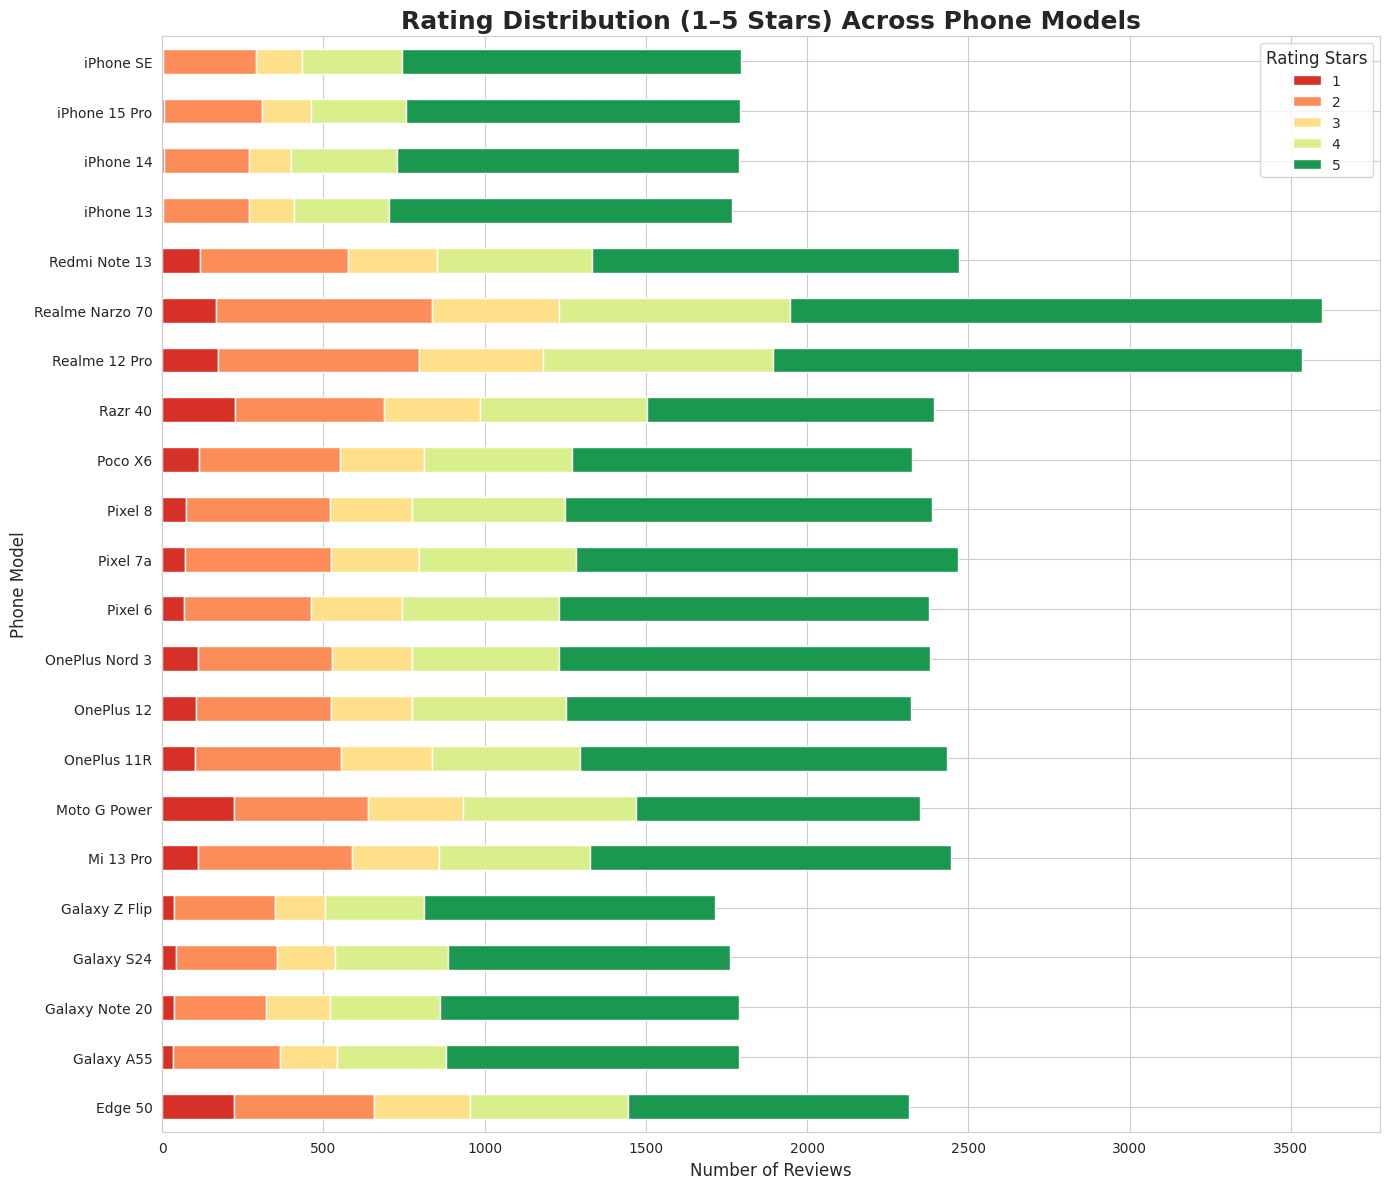

In [ ]:
import matplotlib.pyplot as plt

df['rating_star'] = pd.cut(
    df['rating'],
    bins=[0, 2, 3, 3.5, 4.2, 5.1],
    labels=[1, 2, 3, 4, 5],
    include_lowest=True
).astype(int)

# Count ratings (1,2,3,4,5)

# Convert columns to integers (IMPORTANT FIX!)
rating_dist = df.groupby(['model', 'rating_star']).size().unstack(fill_value=0)


# Sort by model name
rating_dist = rating_dist.sort_index()

# Use exactly 5 colors for 5 stars
colors = {
    1: "#d73027",  # red
    2: "#fc8d59",  # orange
    3: "#fee08b",  # yellow
    4: "#d9ef8b",  # light green
    5: "#1a9850",  # green
}

plt.figure(figsize=(14, 12))  # bigger, readable

rating_dist.plot(
    kind='barh',
    stacked=True,
    color=[colors[r] for r in rating_dist.columns],  # NOW safe
    figsize=(14, 12)
)

plt.title("Rating Distribution (1–5 Stars) Across Phone Models",
          fontsize=18, weight='bold')
plt.xlabel("Number of Reviews", fontsize=12)
plt.ylabel("Phone Model", fontsize=12)

plt.legend(title="Rating Stars", fontsize=10, title_fontsize=12)
plt.tight_layout()
plt.show()


Data Analysis


/tmp/ipython-input-1541033263.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='rating', y='performance_rating', data=df, estimator='mean', ci=None)


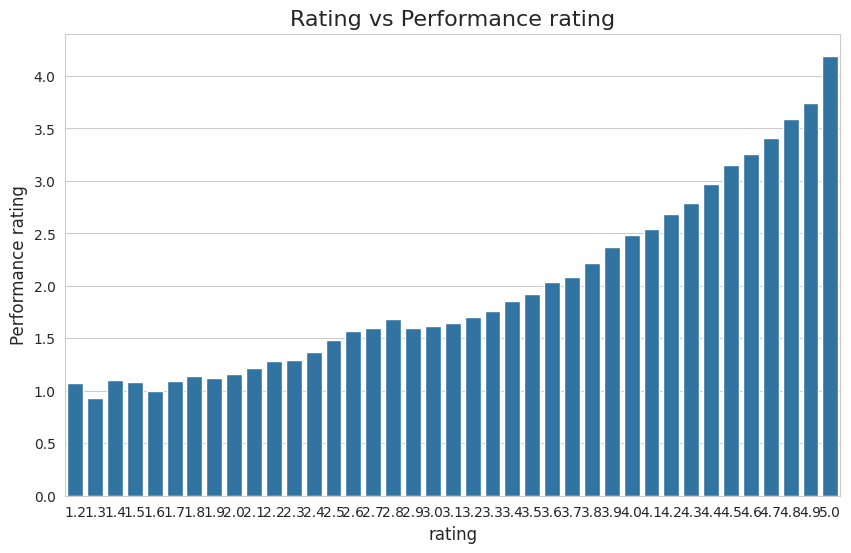

/tmp/ipython-input-1541033263.py:18: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='rating', y='battery_life_rating', data=df, estimator='mean', ci=None)
/tmp/ipython-input-1541033263.py:26: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='rating', y='design_rating', data=df, estimator='mean', ci=None)


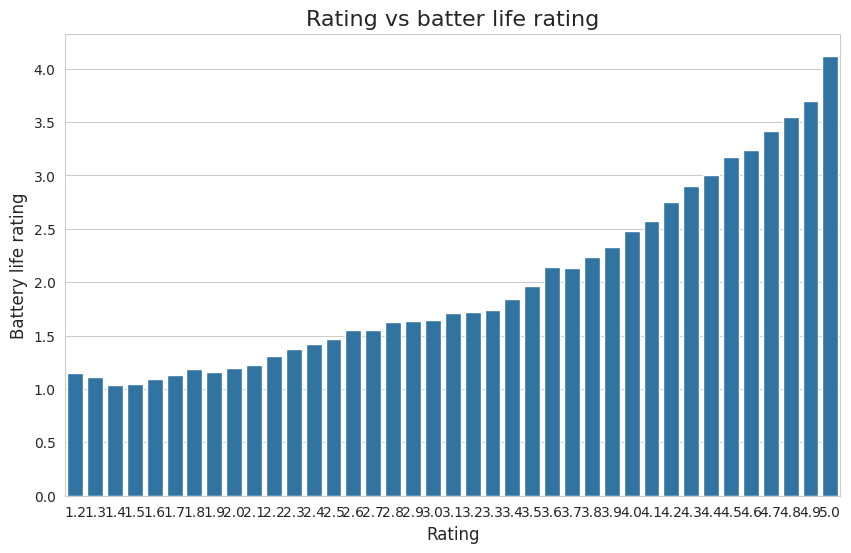

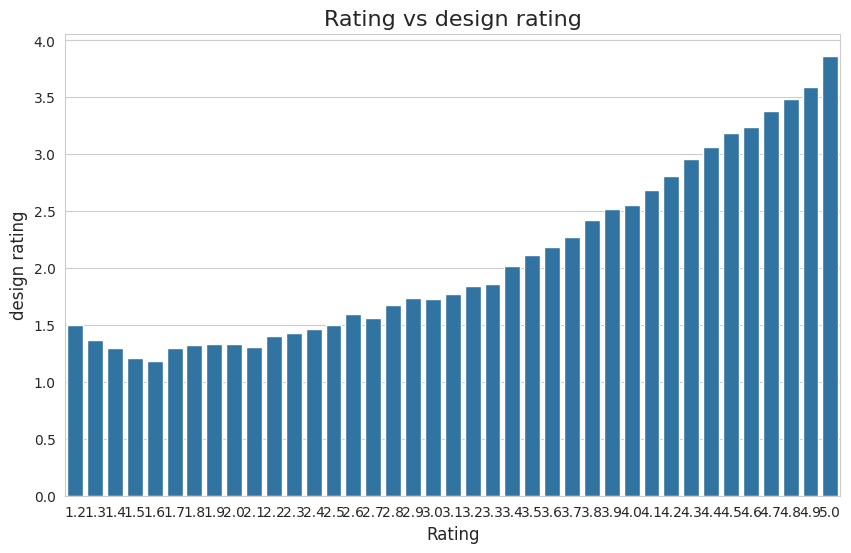

/tmp/ipython-input-1541033263.py:38: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='rating', y='review_length', data=df, estimator='mean', ci=None)


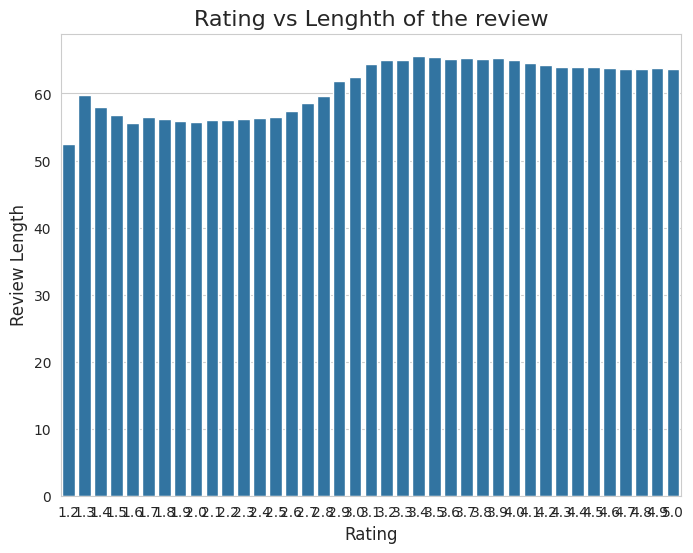

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Bar plot for ant counts based on bread type
plt.figure(figsize=(10,6))
sns.barplot(x='rating', y='performance_rating', data=df, estimator='mean', ci=None)

# Adding title and labels
plt.title('Rating vs Performance rating', fontsize=16)
plt.xlabel('rating', fontsize=12)
plt.ylabel('Performance rating', fontsize=12)

# Show the plot
plt.show()

# Bar plot for ant counts based on topping
plt.figure(figsize=(10,6))
sns.barplot(x='rating', y='battery_life_rating', data=df, estimator='mean', ci=None)

# Adding title and labels
plt.title('Rating vs batter life rating', fontsize=16)
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Battery life rating', fontsize=12)

plt.figure(figsize=(10,6))
sns.barplot(x='rating', y='design_rating', data=df, estimator='mean', ci=None)

# Adding title and labels
plt.title('Rating vs design rating', fontsize=16)
plt.xlabel('Rating', fontsize=12)
plt.ylabel('design rating', fontsize=12)

# Show the plot
plt.show()

# Bar plot for ant counts based on butter presence (0 = No, 1 = Yes)
plt.figure(figsize=(8,6))
sns.barplot(x='rating', y='review_length', data=df, estimator='mean', ci=None)

# Adding title and labels
plt.title('Rating vs Lenghth of the review', fontsize=16)
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Review Length', fontsize=12)

# Show the plot
plt.show()

# Ensure 'rating' is numeric
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

# Recalculate average ratings
avg_rating = df.groupby('brand')['rating'].mean().reset_index()

# Sort by rating for better visualization
avg_rating = avg_rating.sort_values(by='rating', ascending=False)



# Interpretation
#-Performance rating has direct relation on the overall rating
#-Battery life rating has direct relation on the overall rating
#-review lenght does not play significant role on the overall rating
# I could check the ratings based on specific model.
# I could also check which type of phone is famous in different continents





In [ ]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols

# ------------------------------------------------------s
# 1. Categorize features into Poor / Medium / High
#    (Run only once)
# ------------------------------------------------------

df['battery_level'] = pd.cut(
    df['battery_life_rating'],
    bins=[0, 2.4, 3.4, 5],
    labels=['Poor', 'Medium', 'High']
)

df['camera_level'] = pd.cut(
    df['camera_rating'],
    bins=[0, 2.4, 3.4, 5],
    labels=['Poor', 'Medium', 'High']
)

df['performance_level'] = pd.cut(
    df['performance_rating'],
    bins=[0, 2.4, 3.4, 5],
    labels=['Poor', 'Medium', 'High']
)

df['design_level'] = pd.cut(
    df['design_rating'],
    bins=[0, 2.4, 3.4, 5],
    labels=['Poor', 'Medium', 'High']
)

df['display_level'] = pd.cut(
    df['display_rating'],
    bins=[0, 2.4, 3.4, 5],
    labels=['Poor', 'Medium', 'High']
)

# ------------------------------------------------------
# 2. Fit the FULL interaction model:
#    battery * camera * performance * design
# ------------------------------------------------------

import statsmodels.api as sm
from statsmodels.formula.api import ols

formula = """
rating ~
C(battery_level) *
C(camera_level) *
C(performance_level) *
C(design_level) *
C(display_level)
"""

model = ols(formula, data=df).fit()
anova_display = sm.stats.anova_lm(model, typ=2)

print(anova_display)

import numpy as np

def eta_squared(anova):
    anova['eta_sq'] = anova['sum_sq'] / sum(anova['sum_sq'])
    return anova

def partial_eta_squared(anova):
    anova['partial_eta_sq'] = anova['sum_sq'] / (anova['sum_sq'] + anova.loc['Residual','sum_sq'])
    return anova

anova_eta = eta_squared(anova_display.copy())
anova_eta = partial_eta_squared(anova_eta)

print("===== EFFECT SIZES (Eta² and Partial Eta²) =====")
print(anova_eta[['eta_sq','partial_eta_sq']])




                                                          sum_sq       df  \
C(battery_level)                                     1638.152352      2.0   
C(camera_level)                                      1652.529615      2.0   
C(performance_level)                                 2237.700610      2.0   
C(design_level)                                       419.936977      2.0   
C(display_level)                                      387.442913      2.0   
C(battery_level):C(camera_level)                       20.389540      4.0   
C(battery_level):C(performance_level)                  22.442588      4.0   
C(camera_level):C(performance_level)                   28.763803      4.0   
C(battery_level):C(design_level)                       22.088181      4.0   
C(camera_level):C(design_level)                        15.858467      4.0   
C(performance_level):C(design_level)                   16.321947      4.0   
C(battery_level):C(display_level)                      19.371834      4.0   

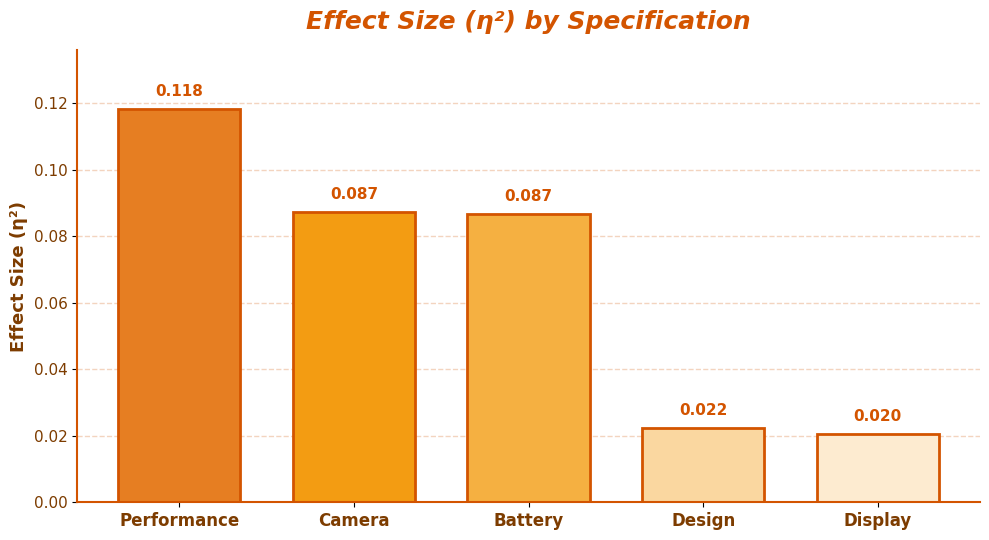

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Your eta-squared values
effect_sizes = {
    "Battery": 0.086589,
    "Camera": 0.087349,
    "Performance": 0.118280,
    "Design": 0.022197,
    "Display": 0.020479
}

es_df = pd.DataFrame({
    "Specification": list(effect_sizes.keys()),
    "Eta_sq": list(effect_sizes.values())
})

# Sort for visual clarity
es_df = es_df.sort_values("Eta_sq", ascending=False)

# Professional orange gradient matching your presentation theme
presentation_oranges = ["#E67E22", "#F39C12", "#F5B041", "#FAD7A0", "#FDEBD0"]

# Create clean, professional figure
fig, ax = plt.subplots(figsize=(10, 5.5), facecolor='white')
ax.set_facecolor('white')

# Create bars
bars = ax.bar(es_df["Specification"], es_df["Eta_sq"],
               color=presentation_oranges,
               edgecolor='#D35400',
               linewidth=2,
               width=0.7)

# Professional title matching your presentation style
plt.title("Effect Size (η²) by Specification",
          fontsize=18,
          fontweight='bold',
          color='#D35400',
          pad=15,
          style='italic')

plt.ylabel("Effect Size (η²)",
           fontsize=13,
           fontweight='bold',
           color='#7D3C00')

plt.xlabel("")

# Clean axis styling
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#D35400')
ax.spines['bottom'].set_color('#D35400')
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

plt.xticks(fontsize=12, fontweight='bold', rotation=0, color='#7D3C00')
plt.yticks(fontsize=11, color='#7D3C00')

# Add value labels above bars - clean and professional
for i, (idx, row) in enumerate(es_df.iterrows()):
    value = row["Eta_sq"]
    ax.text(i, value + 0.003, f"{value:.3f}",
            ha='center',
            va='bottom',
            fontsize=11,
            fontweight='bold',
            color='#D35400')

# Subtle horizontal gridlines for readability
ax.yaxis.grid(True, linestyle='--', alpha=0.25, color='#D35400', linewidth=1)
ax.set_axisbelow(True)

# Set y-axis to start at 0 for proper visual representation
ax.set_ylim(0, max(es_df["Eta_sq"]) * 1.15)

plt.tight_layout()
plt.show()

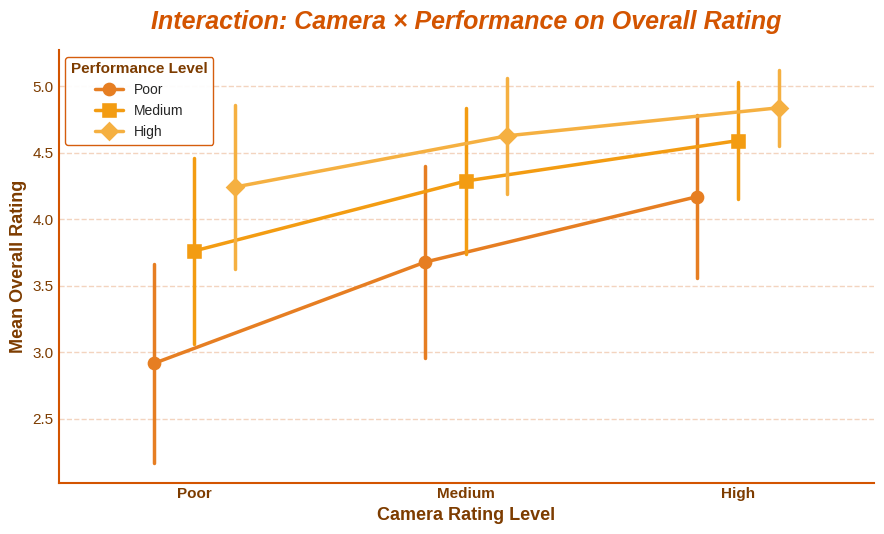

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Make sure these are categorical
df["camera_level"] = df["camera_level"].astype("category")
df["performance_level"] = df["performance_level"].astype("category")

# Professional orange palette for performance levels
orange_palette = ["#E67E22", "#F39C12", "#F5B041"]

# Create clean, professional figure
fig, ax = plt.subplots(figsize=(9, 5.5), facecolor='white')
ax.set_facecolor('white')

# Create the interaction plot
sns.pointplot(
    data=df,
    x="camera_level",
    y="rating",
    hue="performance_level",
    dodge=0.3,
    errorbar="sd",
    markers=["o", "s", "D"],  # Different markers for each level
    markersize=8,
    linewidth=2.5,
    palette=orange_palette,
    ax=ax
)

# Professional title matching your presentation style
plt.title("Interaction: Camera × Performance on Overall Rating",
          fontsize=18,
          fontweight='bold',
          color='#D35400',
          pad=15,
          style='italic')

plt.xlabel("Camera Rating Level",
           fontsize=13,
           fontweight='bold',
           color='#7D3C00')

plt.ylabel("Mean Overall Rating",
           fontsize=13,
           fontweight='bold',
           color='#7D3C00')

# Style the legend
legend = plt.legend(title="Performance Level",
                   title_fontsize=11,
                   fontsize=10,
                   frameon=True,
                   facecolor='white',
                   edgecolor='#D35400',
                   loc='best',
                   framealpha=0.95)
legend.get_title().set_fontweight('bold')
legend.get_title().set_color('#7D3C00')

# Clean axis styling
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#D35400')
ax.spines['bottom'].set_color('#D35400')
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

# Style tick labels
plt.xticks(fontsize=11, fontweight='bold', color='#7D3C00')
plt.yticks(fontsize=11, color='#7D3C00')

# Subtle horizontal gridlines for readability
ax.yaxis.grid(True, linestyle='--', alpha=0.25, color='#D35400', linewidth=1)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

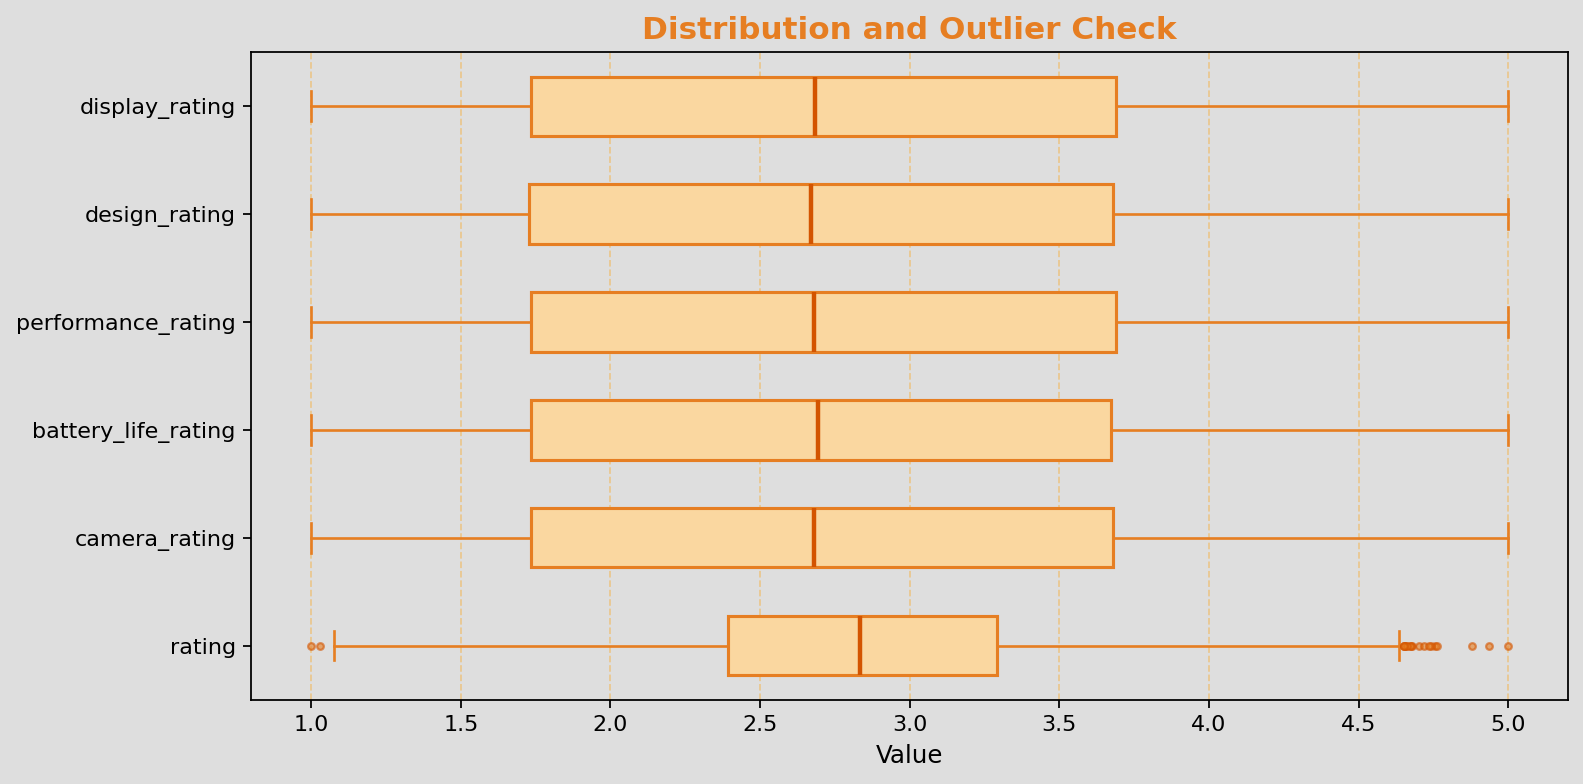

In [ ]:
import matplotlib.pyplot as plt

cols = ["rating", "camera_rating", "battery_life_rating",
        "performance_rating", "design_rating", "display_rating"]

data = [df[c] for c in cols]

plt.figure(figsize=(10, 5), dpi=160, facecolor="#DEDEDE")
ax = plt.gca()
ax.set_facecolor("#DEDEDE")

ax.boxplot(
    data,
    vert=False,
    patch_artist=True,
    widths=0.55,
    boxprops=dict(facecolor="#FAD7A0", edgecolor="#E67E22", linewidth=1.4),
    whiskerprops=dict(color="#E67E22", linewidth=1.2),
    capprops=dict(color="#E67E22", linewidth=1.2),
    medianprops=dict(color="#D35400", linewidth=2),
    flierprops=dict(marker='o', markerfacecolor="#E67E22",
                    markeredgecolor="#D35400", markersize=3, alpha=0.6)
)

ax.set_yticks(range(1, len(cols) + 1))
ax.set_yticklabels(cols, fontsize=10)
ax.set_xlabel("Value", fontsize=11)
ax.set_title("Distribution and Outlier Check", fontsize=14, fontweight="bold", color="#E67E22")

ax.grid(axis="x", linestyle="--", color="#F5B041", alpha=0.5)

plt.tight_layout()
plt.show()
